# UBS and JPMorgan earnings calls: sentence embeddings and cross-bank comparison

Willian Angelo · Team 10 · Bank of England employer project (CAM_DS_401) · release `2026-09-23`

This version keeps JPMorgan's First Republic deal call (1 May 2023) in the cleaned data, fine-tunes the two Sentence-BERT models on the theme examples, and leaves out topic modelling (BERTopic) and the LLM answer key. Those come back when the team compares the models.

Outputs print transcript text. **Clear all outputs before every commit** (public repo, N23).

## Environment

Team setup cell with `NAME = "angelo"`, then `EXPORT = "2026-09-23"` and the smoke test. The cells below expect `ROOT`, `DATA`, `EXPORT` and `loading`.

In [34]:
# 0.0 local Windows only, run before the setup cell: pandas loads pyarrow, whose bundled msvcp140.dll
# is older than the one torch needs, and torch then fails with WinError 1114. Harmless in Colab.
import torch

Loads PyTorch before anything else. On Windows, loading pandas first stops PyTorch from starting, so this line only keeps the notebook running; it does no analysis.

In [35]:
# Phase 0: paste the team setup cell here (NAME = "angelo"), pin EXPORT = "2026-09-23", smoke test

In [36]:
# project setup - run first, do not edit except NAME
NAME = "angelo"  # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")

ok  python 3.13.15  pandas 2.2.3  data c:\local_CAM\Emp_Proj\boe-financial-analysis\data


Standard project set-up: finds the project folder, updates the code from the team's shared branch, installs the pinned library versions and checks them. The output confirms Python 3.13 and pandas 2.2.3, so the results can be reproduced on another machine.

In [37]:
print("exports:", loading.exports(DATA))
print("files:  ", loading.files(DATA, loading.LATEST))
print("banks:  ", loading.firms(DATA, loading.LATEST))

exports: ['2026-09-13', '2026-09-23', 'Never ever upload or change something in the folder above']
files:   []
banks:   []


Lists the data releases available: 13 and 23 September. The empty `files` and `banks` lists come from a known bug in the loader's "latest" option, which is why the next cell names the release explicitly.

In [38]:
EXPORT = "2026-09-23"  # pin the export this notebook was written against

sentences_df = loading.load(DATA, "all_sentences.csv", EXPORT)

loaded all_sentences.csv  9519 rows


Fixes the analysis to the 23 September release and loads its sentence file: 9,519 sentences from the 2023 and 2024 earnings calls of UBS and JPMorgan.

In [39]:
sentences_df

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,19308,1,"Good morning, ladies and gentlemen."
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,19309,2,Welcome to JPMorgan Chase’s First Quarter 2023...
2,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,19310,3,This call is being recorded.
3,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,19311,4,Your line will be muted for the duration of th...
4,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,19312,5,We will now go live to the presentation.
...,...,...,...,...,...,...,...,...,...,...,...,...
9514,UBS,2024-Q4,earnings,2025-02-04,60,qa,management,Sergio P. Ermotti,NaN,19303,2,So there are no more questions.
9515,UBS,2024-Q4,earnings,2025-02-04,60,qa,management,Sergio P. Ermotti,NaN,19304,3,There are no more questions.
9516,UBS,2024-Q4,earnings,2025-02-04,60,qa,management,Sergio P. Ermotti,NaN,19305,4,So thank you for calling in and for your quest...
9517,UBS,2024-Q4,earnings,2025-02-04,60,qa,management,Sergio P. Ermotti,NaN,19306,5,So I'll touch base next quarter.


A first look at the data: one row per sentence, with the bank, quarter, call type, section (prepared remarks or Q&A), speaker role and speaker name.

## Data import and cleaning

In [40]:
# 1.0 settings shared by every phase
try:
    import torch
except OSError as e:
    raise OSError("torch failed to load because pandas loaded first: restart the kernel "
                  "and run the 0.0 cell before the setup cell") from e
import gc, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for name in ("ROOT", "DATA", "EXPORT", "loading"):
    if name not in globals():
        raise NameError(f"run the Environment cell first: {name} is not defined")
if EXPORT not in loading.exports(DATA):
    raise FileNotFoundError(f"release {EXPORT} is not in {DATA / 'results'}")

SEED = 42
OUT = ROOT / "notebooks" / "angelo" / "outputs" / EXPORT   # outputs/ is kept out of git by .git/info/exclude (N23)
if DATA in OUT.parents:
    raise RuntimeError(f"never write inside {DATA}: it holds the read-only release")
OUT.mkdir(parents=True, exist_ok=True)

BANKS = ["UBS", "JPM"]
ROLES = ["analyst", "management"]
QUARTERS = [f"{y}-Q{q}" for y in (2023, 2024) for q in (1, 2, 3, 4)]
CALL_ID = ["bank", "quarter", "call_type"]
TURN = CALL_ID + ["position_in_call"]
KEY = TURN + ["sentence_number"]               # joins results across releases (T20)

# deal stage per call (proposed framing, N1); every call after 2023-Q2 is integration
STAGE = {("UBS", "2023-Q1"): "announced", ("UBS", "2023-Q2"): "closing",
         ("JPM", "2023-Q1"): "before",    ("JPM", "2023-Q2"): "closing"}
STAGE_GROUPS = ["early", "closing", "integration"]

# breaks marked on every time chart (N7)
BREAKS = {"UBS": ("2023-Q2", "Credit Suisse consolidated"),
          "JPM": ("2024-Q2", "Visa gain, CFO-only call")}

# the one event call: JPMorgan's First Republic deal call (1 May 2023), filed under 2023-Q2 next to that
# quarter's earnings call. It stays in the corpus; results per quarter pool it with the earnings call.
EVENT = ("JPM", "2023-Q2", "event")
EVENT_NOTE = "Diamond: JPM's First Republic deal call on its own (1 May 2023)"

# chart style: one fixed colour per bank, recessive grid and axes
BANK_COLOR = {"UBS": "#2a78d6", "JPM": "#eb6834"}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "lines.linewidth": 2,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})
print(f"release {EXPORT}   outputs {OUT}")

release 2026-09-23   outputs c:\local_CAM\Emp_Proj\boe-financial-analysis\notebooks\angelo\outputs\2026-09-23


Sets the constants used throughout: the two banks, the eight quarters, a random seed for repeatable results and the output folder. It also labels each call with its stage in the 2023 acquisitions (UBS bought Credit Suisse, JPMorgan bought First Republic), marks JPMorgan's First Republic deal call of 1 May 2023, and records two quarters whose reported figures jump for known reasons, so the charts can mark them.

In [41]:
# 1.1 load the pinned release
sent_raw = loading.load(DATA, "all_sentences.csv", EXPORT)
utt_raw = loading.load(DATA, "all_utterances.csv", EXPORT)
metrics = loading.load(DATA, "all_metrics.csv", EXPORT)

loaded all_sentences.csv  9519 rows
loaded all_utterances.csv  1201 rows
loaded all_metrics.csv  510 rows


Loads the three tables of the release: 9,519 sentences, 1,201 speaker turns and 510 reported financial figures.

In [42]:
# 1.2 data tests: stop if the release is not what the README describes
FUSED = re.compile(r"\b(?:do|did|does|would|wo|have|are|should|ca|is|was|has|had|were|could)not\b", re.I)
linked = sent_raw.merge(utt_raw[TURN], on=TURN, how="left", indicator=True)
event_calls = set(sent_raw.loc[sent_raw["call_type"] == "event", ["bank", "quarter"]]
                  .itertuples(index=False, name=None))

checks = {
    "9,519 sentences, 1,201 utterances, 510 metric rows":
        (len(sent_raw), len(utt_raw), len(metrics)) == (9519, 1201, 510),
    "sentence_id unique": sent_raw["sentence_id"].is_unique,
    "cross-release key unique": not sent_raw.duplicated(KEY).any(),
    "no nulls in key columns or text":
        sent_raw[KEY + ["section", "speaker_role", "sentence"]].notna().all().all(),
    "section and role values as documented":
        set(sent_raw["section"]) <= {"prepared", "qa"}
        and set(sent_raw["speaker_role"]) <= {"management", "analyst", "ir", "operator"},
    "one event call, JPM 2023-Q2": event_calls == {("JPM", "2023-Q2")},
    "every sentence links to its utterance": linked["_merge"].eq("both").all(),
    "no fused negations left (R13, R15)": not sent_raw["sentence"].str.contains(FUSED).any(),
}
print(pd.Series(checks).map({True: "pass", False: "FAIL"}).to_string())
failed = [name for name, ok in checks.items() if not ok]
if failed:
    raise AssertionError(f"release checks failed: {failed}")

9,519 sentences, 1,201 utterances, 510 metric rows    pass
sentence_id unique                                    pass
cross-release key unique                              pass
no nulls in key columns or text                       pass
section and role values as documented                 pass
one event call, JPM 2023-Q2                           pass
every sentence links to its utterance                 pass
no fused negations left (R13, R15)                    pass


Eight automatic checks that the data matches its documentation: row counts, unique IDs, no missing values, valid categories and an earlier text defect now fixed. All pass; if a later release breaks one, the notebook stops here.

In [43]:
# 1.3 working columns: deal stage, a turn id per utterance and a text key per sentence
def add_columns(df):
    df = df.copy()
    df["stage"] = [STAGE.get(bq, "integration") for bq in zip(df["bank"], df["quarter"])]
    df["stage_group"] = df["quarter"].map({"2023-Q1": "early", "2023-Q2": "closing"}).fillna("integration")
    df["turn_id"] = df[TURN].astype(str).agg("|".join, axis=1)
    return df

sent = add_columns(sent_raw)
utt = add_columns(utt_raw)
sent["key"] = sent[KEY].astype(str).agg("|".join, axis=1)

Adds three helper columns to each sentence: the deal stage of its call, the speaker turn it belongs to, and a unique key used later to join results with other analyses.

In [44]:
# 1.4 approximate Q&A exchanges: a new exchange starts when a different analyst speaks.
# Follow-ups by the same analyst stay in it; management answers inherit it.
# John's qa_exchange_id replaces this once it is versioned with the release (N26).
turns = utt[utt["section"] == "qa"].sort_values(TURN)
analyst = turns[turns["speaker_role"] == "analyst"]
new_exchange = analyst["speaker_name"].ne(analyst.groupby(CALL_ID)["speaker_name"].shift())
utt["exchange"] = (new_exchange.astype(int).reindex(turns.index, fill_value=0)
                   .groupby([turns[c] for c in CALL_ID]).cumsum())
call_id = utt["bank"] + "|" + utt["quarter"] + "|" + utt["call_type"]
utt["exchange_id"] = (call_id + "|" + utt["exchange"].astype("Int64").astype(str)).where(utt["exchange"].notna())
sent = sent.merge(utt[["turn_id", "exchange", "exchange_id"]], on="turn_id", how="left", validate="many_to_one")

print("approximate exchanges per call")
print(utt.groupby(CALL_ID)["exchange"].max().unstack("quarter").astype("Int64").to_string())

approximate exchanges per call
quarter         2023-Q1  2023-Q2  2023-Q3  2023-Q4  2024-Q1  2024-Q2  2024-Q3  2024-Q4
bank call_type                                                                        
JPM  earnings        11       12       10       10       11       10       10        8
     event         <NA>        8     <NA>     <NA>     <NA>     <NA>     <NA>     <NA>
UBS  earnings        13       13       10       14       10        9       10       11


Groups the Q&A into exchanges (an analyst's question with management's answers and follow-ups), starting a new exchange whenever a different analyst speaks. Each earnings call has 8 to 14 exchanges, and JPMorgan's First Republic deal call has 8.

In [45]:
# 1.5 transformer path (N13): keep raw sentences, strip UBS editorial brackets, flag filler rows
BRACKET = re.compile(r"\[[^\]]*\]")
sent["had_bracket"] = sent["sentence"].str.contains(BRACKET)
sent["text"] = (sent["sentence"].str.replace(BRACKET, " ", regex=True)
                .str.replace(r"\s+([,.;:?!])", r"\1", regex=True)
                .str.replace(r"\s{2,}", " ", regex=True).str.strip())
sent["n_words"] = sent["text"].str.split().str.len()

# a filler row has 4 words or fewer, or 12 words or fewer and matches a pleasantry pattern
MAX_SHORT, MAX_PLEASANTRY = 4, 12
PLEASANTRY = [
    r"^\W*(?:(?:yeah|yes|okay|ok|so|and|well|great|perfect|first of all|all right)\W+)*(?:thanks|thank you)\b",
    r"\bgood (?:morning|afternoon|evening)\b",
    r"\b(?:congratulations|congrats|welcome back)\b",
    r"\btaking my questions?\b",
    r"\b(?:thanks|thank you) for the questions?\b",
    r"\b(?:it's|that's|that is|a) (?:a )?(?:very |really )?(?:good|great|fair|interesting) question\b",
    r"^\W*(?:(?:okay|ok|yeah|yes|great|so|no)\W+)*(?:that's|that is|that was|very|super|really|extremely) helpful\b",
    r"\bthat's (?:my|the) (?:first|second|last|final) question\b",
    r"^\W*(?:(?:so|and|just|okay|yeah|i have|i've got|i got|i just got)\W+)*"
    r"(?:two|2|three|a couple(?: of)?|couple of|a few|one more|a quick|one|last)\W+(?:quick\W+)?"
    r"(?:questions?|follow-ups?)(?:\W+(?:from me|for me|please|if i may|if i could|again))*\W*$",
    r"\b(?:go to|take) the next question\b|\bback (?:in|into) the queue\b|\benjoy the rest\b",
]
PLEASANTRY_RE = re.compile("|".join(f"(?:{p})" for p in PLEASANTRY), re.I)
plain = sent["text"].str.replace("\u2019", "'", regex=False)      # curly apostrophes
sent["filler"] = np.select(
    [sent["n_words"] <= MAX_SHORT,
     (sent["n_words"] <= MAX_PLEASANTRY) & plain.str.contains(PLEASANTRY_RE)],
    ["short", "pleasantry"], default="")

Prepares the text for the language models without rewriting it: removes editorial notes in square brackets and flags "filler" sentences such as "Thank you." or "That's my first question", which carry no business content.

In [46]:
# 1.6 filter funnel and two corpora: Q&A for the analysis, prepared remarks kept for A3.
# The First Republic deal call stays in: it is JPMorgan's own communication about its acquisition.
steps = {
    "all sentences": pd.Series(True, index=sent.index),
    "Q&A section only": sent["section"] == "qa",
    "analysts and management (operator, IR out)": sent["speaker_role"].isin(ROLES),
    "filler rows dropped": sent["filler"] == "",
}
keep, rows = pd.Series(True, index=sent.index), []
for step, cond in steps.items():
    keep &= cond
    n = sent.loc[keep, "bank"].value_counts()
    rows.append({"step": step, **{b: int(n.get(b, 0)) for b in BANKS}, "total": int(keep.sum())})
funnel = pd.DataFrame(rows).set_index("step")
funnel["kept_%"] = (100 * funnel["total"] / funnel["total"].iloc[0]).round(1)

qa = sent[keep].reset_index(drop=True)
prep = sent[(sent["section"] == "prepared") & (sent["speaker_role"] == "management")
            & (sent["filler"] == "")].reset_index(drop=True)
display(funnel)
print(f"Q&A corpus {len(qa):,} sentences · prepared-remarks corpus {len(prep):,} sentences")
print("from the JPM deal call:", {"Q&A": int((qa["call_type"] == "event").sum()),
                                  "prepared": int((prep["call_type"] == "event").sum())})
print("editorial brackets stripped in the Q&A corpus:", qa.groupby("bank")["had_bracket"].sum().to_dict())

,UBS,JPM,total,kept_%
step,,,,
all sentences,4714,4805,9519,100.0
Q&A section only,2653,3863,6516,68.5
"analysts and management (operator, IR out)",2648,3595,6243,65.6
filler rows dropped,2021,2667,4688,49.2


Q&A corpus 4,688 sentences · prepared-remarks corpus 2,837 sentences
from the JPM deal call: {'Q&A': 169, 'prepared': 45}
editorial brackets stripped in the Q&A corpus: {'JPM': 2, 'UBS': 10}


Builds the analysis dataset step by step: Q&A only, analysts and management only, filler removed. The 9,519 sentences become 4,688: 2,021 from UBS and 2,667 from JPMorgan, 169 of which come from the First Republic deal call. The Q&A is used because it is unscripted; the prepared remarks (2,837 sentences) are kept aside.

In [47]:
# 1.7 check the filler rule: what it dropped and what it cost.
# Prints transcript text: clear outputs before committing.
pre = sent[(sent["section"] == "qa") & sent["speaker_role"].isin(ROLES)]
dropped = pre[pre["filler"] != ""]
display(pd.crosstab([dropped["bank"], dropped["speaker_role"]], dropped["filler"], margins=True))

with_number = dropped["text"].str.contains(r"\d")
print(f"dropped sentences that contain a number: {with_number.sum()} of {len(dropped):,}")
print(dropped.loc[with_number, "text"].head(10).to_string(index=False))
for reason in ("short", "pleasantry"):
    print(f"\n{reason}: 10 random examples")
    for s in dropped.loc[dropped["filler"] == reason, "text"].sample(10, random_state=SEED):
        print("   ", s)
print("\nmost frequent dropped sentences")
print(dropped["text"].value_counts().head(12).to_string())

filler             pleasantry  short   All
bank speaker_role                         
JPM  analyst               23    476   499
     management            14    415   429
UBS  analyst               56    396   452
     management             9    166   175
All                       102   1453  1555

dropped sentences that contain a number: 11 of 1,555
            It’s still 5.8%.
                   I 100%...
              $22.5 billion.
     She said $22.9 billion.
       The minimum is 11.9%.
       $2 billion a quarter.
           Markets about 6%.
     Markets is $87 billion.
         Consensus is at 9%.
2Q was exceptionally strong.

short: 10 random examples
    That's helpful.
    Okay.
    Yes.
    Thanks.
    Good morning.
    Yeah.
    Thanks, Gerard.
    So, again, watching it.
    Good morning.
    Good question, Jim.

pleasantry: 10 random examples
    It's a good question, Ebrahim.
    Thanks for the presentation and for taking my questions.
    Thank you for calling in and enjoy the rest of the day.
    And thanks for taking my questions.
    And welcome back, Sergio, from me as well.
    Thank you and welcome back, Sergio, too from me.
    So two questions from me.
    So that's my first question.
    So that's my first question.
    I'll hop back into the queue.

mo

Checks what the filler rule removed: 1,555 sentences, almost all courtesies ("Thank you." alone appears 199 times). Only 11 contain a number, and none of those makes sense on its own.

In [48]:
# 1.9 save the cleaned corpora (parquet, in the outputs folder)
cols = ["key", "sentence_id", "bank", "quarter", "call_type", "call_date", "position_in_call",
        "sentence_number", "speaker_role", "speaker_name", "speaker_institution", "stage",
        "stage_group", "turn_id", "exchange_id", "text", "n_words"]
qa[cols].to_parquet(OUT / "qa_sentences.parquet", index=False)
prep[cols].to_parquet(OUT / "prepared_sentences.parquet", index=False)
funnel.to_csv(OUT / "filter_funnel.csv")
display(qa.pivot_table(index=["bank", "call_type"], columns="speaker_role", values="key", aggfunc="count",
                       margins=True))

speaker_role    analyst  management   All
bank call_type                           
JPM  earnings       677        1821  2498
     event           58         111   169
UBS  earnings       700        1321  2021
All                1435        3253  4688

Saves the cleaned datasets. The final Q&A set has 700 analyst and 1,321 management sentences for UBS. JPMorgan has 677 and 1,821 on its earnings calls, plus 58 and 111 on the deal call.

### Summary

The 23 September release passes all eight data checks. Of 9,519 sentences, 4,688 form the analysis corpus: Q&A only, analysts and management only, filler removed (UBS 2,021, JPMorgan 2,667). JPMorgan's First Republic deal call of 1 May 2023 is kept because it is the bank's own account of its acquisition; it adds 169 sentences, filed under 2023-Q2 next to that quarter's earnings call. The filler rule removed 1,555 sentences (1,453 short, 102 courtesy), and only 11 of them contain a number, none of which makes sense on its own. The prepared remarks (2,837 management sentences) are kept apart for later work. Saved under `notebooks/angelo/outputs/2026-09-23/`: `qa_sentences.parquet`, `prepared_sentences.parquet` and `filter_funnel.csv`.

Every later number rests on a checked, documented corpus, and each exclusion has a stated reason and a count. A supervisor can see exactly what went in and what was left out.

## Initial data investigation

In [49]:
# 2.0 chart helpers: quarters on the x axis, one line per bank, breaks as dotted lines
from matplotlib.colors import LinearSegmentedColormap
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
QLABELS = [q[2:] for q in QUARTERS]                                    # 23-Q1 ...
BREAK_NOTE = "Dotted lines: " + " · ".join(f"{b} {q}, {why}" for b, (q, why) in BREAKS.items())
FIG = OUT / "figures"                                                  # charts saved for the slides
FIG.mkdir(exist_ok=True)
EVENT_X = QUARTERS.index(EVENT[1]) - 0.3                               # just left of JPM's 2023-Q2 point

def quarter_axis(ax):
    ax.set_xticks(range(len(QUARTERS)), QLABELS)
    ax.set_xlim(-0.4, len(QUARTERS) - 0.2)

def mark_breaks(ax, banks=BANKS):
    for b in banks:
        ax.axvline(QUARTERS.index(BREAKS[b][0]), color=BANK_COLOR[b], lw=1, ls=":", zorder=0)

def mark_event(ax, value, label="JPM deal call"):
    # the First Republic deal call alone, as a hollow diamond beside the 2023-Q2 point
    ax.scatter([EVENT_X], [value], marker="D", s=40, facecolors="white", edgecolors=BANK_COLOR["JPM"],
               linewidths=1.5, zorder=4, label=label)

def bank_lines(ax, series, title):
    # series indexed by (bank, quarter); each line labelled at its last point
    for b in BANKS:
        s = series.xs(b, level="bank").reindex(QUARTERS).astype(float)
        ax.plot(range(len(QUARTERS)), s.to_numpy(), color=BANK_COLOR[b], marker="o", ms=4, label=b)
        last = s.last_valid_index()
        if last is not None:
            ax.annotate(b, (QUARTERS.index(last), s[last]), xytext=(6, 0), textcoords="offset points",
                        va="center", fontsize=8, color="#52514e")
    quarter_axis(ax)
    mark_breaks(ax)
    ax.set_title(title, loc="left")

No output: defines the chart style. UBS is always blue and JPMorgan orange, quarters run left to right, dotted lines mark the two quarters with known breaks in the figures, and a hollow diamond shows JPMorgan's deal call on its own.

In [50]:
# 2.1 coverage: statements and sentences per call, checked against the README table
README_COUNTS = {
    ("JPM", "2023-Q1", "earnings"): (112, 557), ("JPM", "2023-Q2", "event"): (75, 319),
    ("JPM", "2023-Q2", "earnings"): (117, 581), ("JPM", "2023-Q3", "earnings"): (103, 569),
    ("JPM", "2023-Q4", "earnings"): (72, 462),  ("JPM", "2024-Q1", "earnings"): (85, 641),
    ("JPM", "2024-Q2", "earnings"): (76, 505),  ("JPM", "2024-Q3", "earnings"): (95, 665),
    ("JPM", "2024-Q4", "earnings"): (80, 506),  ("UBS", "2023-Q1", "earnings"): (52, 539),
    ("UBS", "2023-Q2", "earnings"): (45, 672),  ("UBS", "2023-Q3", "earnings"): (40, 534),
    ("UBS", "2023-Q4", "earnings"): (61, 804),  ("UBS", "2024-Q1", "earnings"): (50, 501),
    ("UBS", "2024-Q2", "earnings"): (42, 447),  ("UBS", "2024-Q3", "earnings"): (36, 508),
    ("UBS", "2024-Q4", "earnings"): (60, 709),
}
coverage = pd.DataFrame({
    "statements": utt.groupby(CALL_ID).size(),
    "sentences": sent.groupby(CALL_ID).size(),
    "qa_sentences": sent[sent["section"] == "qa"].groupby(CALL_ID).size(),
    "analysis_corpus": qa.groupby(CALL_ID).size(),
}).fillna(0).astype(int)
coverage["matches_README"] = [README_COUNTS.get(i) == (r.statements, r.sentences)
                              for i, r in coverage.iterrows()]
display(coverage)
assert coverage["matches_README"].all(), "counts differ from the README"
display(pd.crosstab([sent["bank"], sent["section"]], sent["speaker_role"], margins=True))

statements  sentences  qa_sentences  analysis_corpus  \
bank quarter call_type                                                         
JPM  2023-Q1 earnings          112        557           445              300   
     2023-Q2 earnings          117        581           462              304   
             event              75        319           263              169   
     2023-Q3 earnings          103        569           437              306   
     2023-Q4 earnings           72        462           342              231   
     2024-Q1 earnings           85        641           540              381   
     2024-Q2 earnings           76        505           407              281   
     2024-Q3 earnings           95        665           583              434   
     2024-Q4 earnings           80        506           384              261   
UBS  2023-Q1 earnings           52        539           361              276   
     2023-Q2 earnings           45        672           382              302   
     2023-Q3 earnings           40        534           318              241   
     2023-Q4 earnings           61        804           451              344   
     2024-Q1 earnings           50        501           292              218   
     2024-Q2 earnings           42        447           239              188   
     2024-Q3 earnings           36        508           291              221   
     2024-Q4 earnings           60        709           319              231   

                        matches_README  
bank quarter call_type                  
JPM  2023-Q1 earnings             True  
     2023-Q2 earnings             True  
             event                True  
     2023-Q3 earnings             True  
     2023-Q4 earnings             True  
     2024-Q1 earnings             True  
     2024-Q2 earnings             True  
     2024-Q3 earnings             True  
     2024-Q4 earnings             True  
UBS  2023-Q1 earnings             True  
     2023-Q2 earnings             True  
     2023-Q3 earnings             True  
     2023-Q4 earnings             True  
     2024-Q1 earnings             True  
     2024-Q2 earnings             True  
     2024-Q3 earnings             True  
     2024-Q4 earnings             True

speaker_role   analyst  ir  management  operator   All
bank section                                          
JPM  prepared        0   0         865        77   942
     qa           1234   0        2361       268  3863
UBS  prepared        0   0        2061         0  2061
     qa           1152   5        1496         0  2653
All               2386   5        6783       345  9519

Confirms that all 17 calls are complete and match the documented counts; the analysis-corpus column shows how many sentences of each call are used, 169 of them from the deal call. It also shows the calls are built differently: UBS opens with long prepared remarks, while JPMorgan's calls are mostly Q&A, so the banks are compared on shares rather than raw counts.

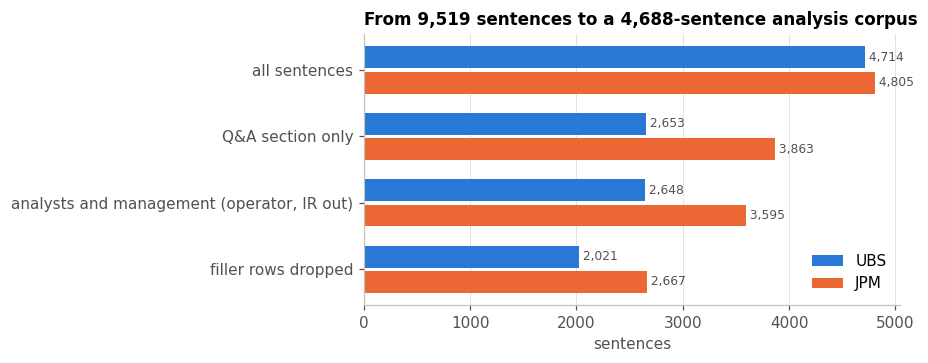

sentences  filler  filler_%
bank speaker_role                             
JPM  analyst            1234     499      40.4
     management         2361     429      18.2
UBS  analyst            1152     452      39.2
     management         1496     175      11.7

In [51]:
# 2.2 filter funnel with reasons, and the filler share by bank and role (N13)
fig, ax = plt.subplots(figsize=(8.5, 3.4))
y, h = np.arange(len(funnel)), 0.38
for i, b in enumerate(BANKS):
    ys = y + (i - 0.5) * h
    ax.barh(ys, funnel[b], height=h - 0.05, color=BANK_COLOR[b], label=b)
    for yy, v in zip(ys, funnel[b]):
        ax.text(v, yy, f" {v:,}", va="center", fontsize=8, color="#52514e")
ax.set_yticks(y, funnel.index)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("sentences")
ax.legend(loc="lower right")
ax.set_title(f"From {funnel['total'].iloc[0]:,} sentences to a "
             f"{funnel['total'].iloc[-1]:,}-sentence analysis corpus", loc="left")
plt.tight_layout()
plt.show()

filler_share = (pre.assign(filler_row=pre["filler"] != "")
                .groupby(["bank", "speaker_role"])["filler_row"].agg(sentences="size", filler="sum"))
filler_share["filler_%"] = (100 * filler_share["filler"] / filler_share["sentences"]).round(1)
display(filler_share)

Charts the filtering steps and shows how much of each group was filler: about 40% of analyst sentences at both banks, against 12% (UBS) and 18% (JPMorgan) of management sentences.

utterances  median_chars  median_tokens  over_MiniLM_pct  \
bank speaker_role                                                             
JPM  analyst              319         224.0           50.0              0.6   
     management           366         415.5          101.5             23.0   
UBS  analyst              194         229.5           56.0              5.7   
     management           169        1007.0          228.0             38.5   

                   over_mpnet_pct  qa_sentences_per_utterance  
bank speaker_role                                              
JPM  analyst                  0.0                         3.9  
     management               8.2                         6.5  
UBS  analyst                  0.0                         5.9  
     management              18.3                         8.9

clean sentences longer than the MiniLM limit: 0 of 4,688 (longest 172 word-pieces)


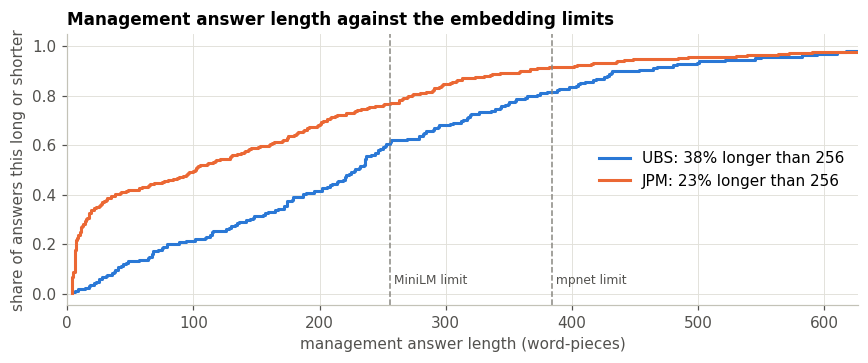

In [52]:
# 2.3 answer length in MiniLM word-pieces: how much of an answer an utterance-level embedding sees (N25)
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
tok.model_max_length = 1_000_000          # counting only, so no truncation warning
LIMITS = {"MiniLM": 256, "mpnet": 384}    # max_seq_length of the two sentence-transformers

def n_tokens(texts):
    return np.array([len(ids) for ids in tok(list(texts))["input_ids"]])

answers = utt[(utt["section"] == "qa") & utt["speaker_role"].isin(ROLES)].copy()
answers["tokens"] = n_tokens(answers["text"])
qa["tokens"] = n_tokens(qa["text"])

length = answers.groupby(["bank", "speaker_role"]).agg(
    utterances=("tokens", "size"),
    median_chars=("text_length", "median"),
    median_tokens=("tokens", "median"),
    over_MiniLM_pct=("tokens", lambda t: 100 * (t > LIMITS["MiniLM"]).mean()),
    over_mpnet_pct=("tokens", lambda t: 100 * (t > LIMITS["mpnet"]).mean()))
length["qa_sentences_per_utterance"] = (pre.groupby(["bank", "speaker_role", "turn_id"]).size()
                                        .groupby(["bank", "speaker_role"]).mean())
display(length.round(1))
print(f"clean sentences longer than the MiniLM limit: {(qa['tokens'] > LIMITS['MiniLM']).sum()} "
      f"of {len(qa):,} (longest {qa['tokens'].max()} word-pieces)")

fig, ax = plt.subplots(figsize=(8, 3.4))
mgmt = answers[answers["speaker_role"] == "management"]
for b in BANKS:
    t = np.sort(mgmt.loc[mgmt["bank"] == b, "tokens"].to_numpy())
    ax.step(t, np.arange(1, len(t) + 1) / len(t), where="post", color=BANK_COLOR[b],
            label=f"{b}: {100 * (t > LIMITS['MiniLM']).mean():.0f}% longer than {LIMITS['MiniLM']}")
for name, lim in LIMITS.items():
    ax.axvline(lim, color="#898781", lw=1, ls="--")
    ax.text(lim, 0.04, f" {name} limit", fontsize=8, color="#52514e")
ax.set_xlim(0, mgmt["tokens"].quantile(0.98))
ax.set_xlabel("management answer length (word-pieces)")
ax.set_ylabel("share of answers this long or shorter")
ax.set_title("Management answer length against the embedding limits", loc="left")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

Measures answer length against the input limit of the embedding models (256 word-pieces for MiniLM, 384 for mpnet); text beyond the limit is ignored. 38% of UBS management answers exceed 256, against 23% at JPMorgan. No single sentence exceeds it (the longest has 172), which is why the analysis works on sentences rather than whole answers.

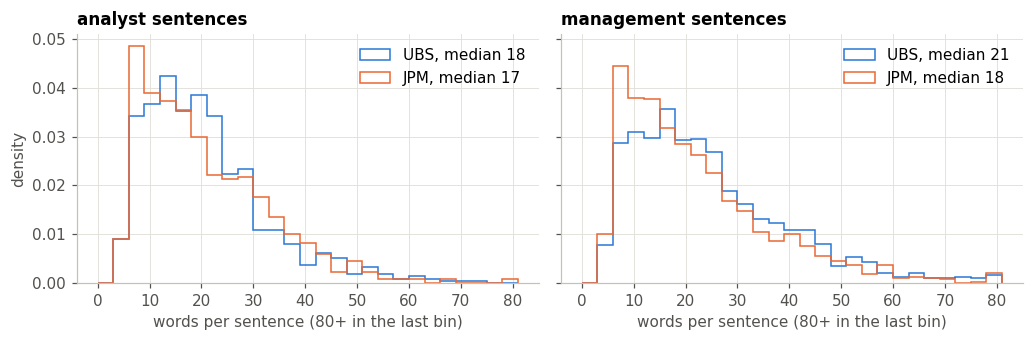

count  mean   std  min   50%   95%    max
bank speaker_role                                            
JPM  analyst        735.0  20.2  12.2  5.0  17.0  43.0   78.0
     management    1932.0  21.7  14.7  5.0  18.0  49.4  139.0
UBS  analyst        700.0  20.4  11.9  5.0  18.0  45.0   73.0
     management    1321.0  24.2  15.0  5.0  21.0  53.0  132.0

In [53]:
# 2.4 sentence length after cleaning, by bank and role
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
bins = np.arange(0, 82, 3)
for ax, role in zip(axes, ROLES):
    for b in BANKS:
        w = qa.loc[(qa["bank"] == b) & (qa["speaker_role"] == role), "n_words"]
        ax.hist(w.clip(upper=80), bins=bins, density=True, histtype="step", lw=2,
                color=BANK_COLOR[b], label=f"{b}, median {w.median():.0f}")
    ax.set_title(f"{role} sentences", loc="left")
    ax.set_xlabel("words per sentence (80+ in the last bin)")
    ax.legend()
axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()
display(qa.groupby(["bank", "speaker_role"])["n_words"].describe(percentiles=[0.5, 0.95]).round(1))

Sentence lengths are similar at both banks (median 17 to 21 words), so later differences come from content, not from sentence length.

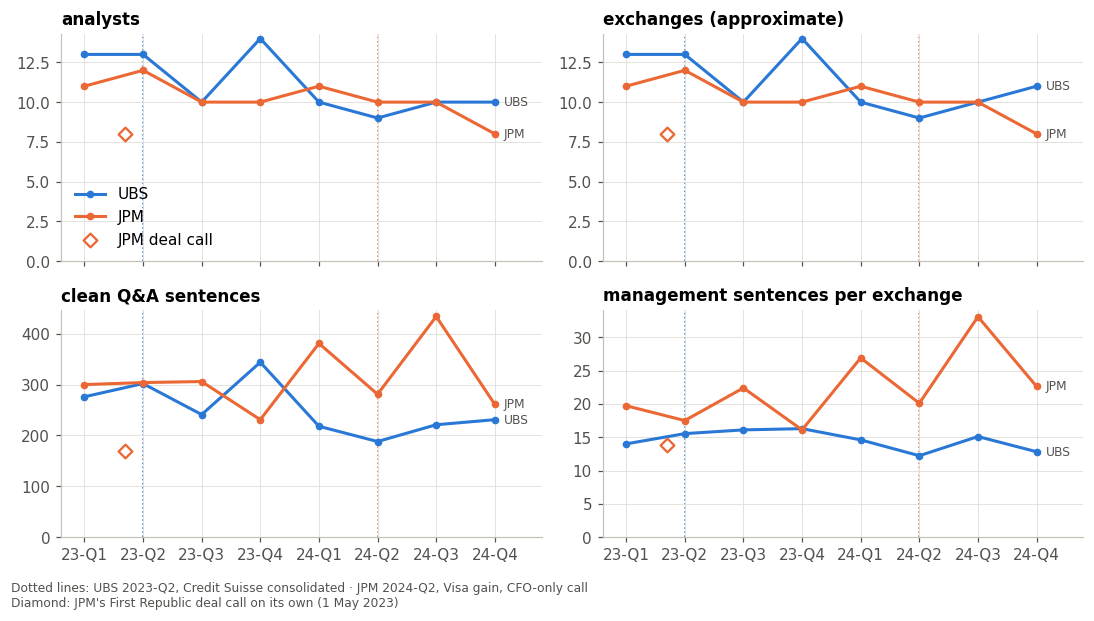

analysts  exchanges (approximate)  \
bank quarter call_type                                      
JPM  2023-Q1 earnings         11                     11.0   
     2023-Q2 earnings         12                     12.0   
             event             8                      8.0   
     2023-Q3 earnings         10                     10.0   
     2023-Q4 earnings         10                     10.0   
     2024-Q1 earnings         11                     11.0   
     2024-Q2 earnings         10                     10.0   
     2024-Q3 earnings         10                     10.0   
     2024-Q4 earnings          8                      8.0   
UBS  2023-Q1 earnings         13                     13.0   
     2023-Q2 earnings         13                     13.0   
     2023-Q3 earnings         10                     10.0   
     2023-Q4 earnings         14                     14.0   
     2024-Q1 earnings         10                     10.0   
     2024-Q2 earnings          9                      9.0   
     2024-Q3 earnings         10                     10.0   
     2024-Q4 earnings         10                     11.0   

                        clean Q&A sentences  management sentences  \
bank quarter call_type                                              
JPM  2023-Q1 earnings                   300                   217   
     2023-Q2 earnings                   304                   210   
             event                      169                   111   
     2023-Q3 earnings                   306                   224   
     2023-Q4 earnings                   231                   161   
     2024-Q1 earnings                   381                   296   
     2024-Q2 earnings                   281                   201   
     2024-Q3 earnings                   434                   331   
     2024-Q4 earnings                   261                   181   
UBS  2023-Q1 earnings                   276                   182   
     2023-Q2 earnings                   302                   202   
     2023-Q3 earnings                   241                   161   
     2023-Q4 earnings                   344                   228   
     2024-Q1 earnings                   218                   146   
     2024-Q2 earnings                   188                   110   
     2024-Q3 earnings                   221                   151   
     2024-Q4 earnings                   231                   141   

                        management sentences per exchange  
bank quarter call_type                                     
JPM  2023-Q1 earnings                                19.7  
     2023-Q2 earnings                                17.5  
             event                                   13.9  
     2023-Q3 earnings                                22.4  
     2023-Q4 earnings                                16.1  
     2024-Q1 earnings                                26.9  
     2024-Q2 earnings                                20.1  
     2024-Q3 earnings                                33.1  
     2024-Q4 earnings                                22.6  
UBS  2023-Q1 earnings                                14.0  
     2023-Q2 earnings                                15.5  
     2023-Q3 earnings                                16.1  
     2023-Q4 earnings                                16.3  
     2024-Q1 earnings                                14.6  
     2024-Q2 earnings                                12.2  
     2024-Q3 earnings                                15.1  
     2024-Q4 earnings                                12.8

In [54]:
# 2.5 Q&A volume per call: analysts, exchanges, and how much management says per exchange.
# Lines: the earnings calls; diamond: the JPM deal call on its own.
turns = utt[utt["section"] == "qa"]
volume = pd.DataFrame({
    "analysts": turns[turns["speaker_role"] == "analyst"].groupby(CALL_ID)["speaker_name"].nunique(),
    "exchanges (approximate)": turns.groupby(CALL_ID)["exchange"].max(),
    "clean Q&A sentences": qa.groupby(CALL_ID).size(),
    "management sentences": qa[qa["speaker_role"] == "management"].groupby(CALL_ID).size(),
})
volume["management sentences per exchange"] = (volume["management sentences"]
                                               / volume["exchanges (approximate)"])
panels = ["analysts", "exchanges (approximate)", "clean Q&A sentences", "management sentences per exchange"]
fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), sharex=True)
for ax, col in zip(axes.flat, panels):
    bank_lines(ax, volume[col].xs("earnings", level="call_type"), col)
    mark_event(ax, volume.loc[EVENT, col])
    ax.set_ylim(bottom=0)
axes[0, 0].legend(loc="lower left")
fig.text(0.01, 0.005, BREAK_NOTE + "\n" + EVENT_NOTE, fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()
display(volume.round(1))

Q&A volume per call: both banks take questions from 8 to 14 analysts, but JPMorgan management says more per exchange (16 to 33 sentences, against 12 to 16 at UBS). The deal call (the diamond) was shorter: 8 analysts, 169 clean sentences and about 14 management sentences per exchange.

In [55]:
# 2.6 who asks: analysts and houses per bank, and the houses on both banks' calls
an = utt[utt["speaker_role"] == "analyst"]
houses = an.groupby(["speaker_institution", "bank"])["speaker_name"].nunique().unstack(fill_value=0)
both = houses[(houses > 0).all(axis=1)]
people_both = set(an.loc[an["bank"] == "UBS", "speaker_name"]) & set(an.loc[an["bank"] == "JPM", "speaker_name"])
print(f"analysts: UBS {an.loc[an['bank'] == 'UBS', 'speaker_name'].nunique()}, "
      f"JPM {an.loc[an['bank'] == 'JPM', 'speaker_name'].nunique()}; "
      f"same person on both banks' calls: {sorted(people_both) or 'none'}")
print(f"houses on both banks' calls: {len(both)} of {len(houses)} (analysts per house)")
display(both)

analysts: UBS 18, JPM 16; same person on both banks' calls: none
houses on both banks' calls: 5 of 26 (analysts per house)


bank,JPM,UBS
speaker_institution,,
Autonomous Research,1,1
Bank of America,1,2
Deutsche Bank,1,1
Jefferies,1,1
Morgan Stanley,3,2


Who asks the questions: 18 analysts at UBS and 16 at JPMorgan, none covering both, and only 5 of 26 research firms on both banks' calls. Some differences between the banks may therefore come from different people asking.

In [56]:
# 2.7 keyword baseline for merger talk: the "before" for the semantic filter in Phase 4 (N20)
MERGER_KW = re.compile(r"(?i:credit suisse|first republic|\bintegrat\w*|\bacquisi\w*|\bmerger\w*)|\bCS\b|\bFRC\b")
qa["merger_keyword"] = qa["text"].str.contains(MERGER_KW)
kw = (qa.pivot_table(index=["bank", "call_type"], columns="quarter", values="merger_keyword", aggfunc="sum")
        .reindex(columns=QUARTERS))
kw["total"] = kw.sum(axis=1)
kw["share_%"] = (100 * kw["total"] / qa.groupby(["bank", "call_type"]).size()).round(1)
display(kw)
print("share of each bank's sentences, all calls:",
      (100 * qa.groupby("bank")["merger_keyword"].mean()).round(1).to_dict())

quarter         2023-Q1  2023-Q2  2023-Q3  2023-Q4  2024-Q1  2024-Q2  2024-Q3  \
bank call_type                                                                  
JPM  earnings       1.0      5.0     11.0     12.0      9.0      2.0      3.0   
     event          NaN     19.0      NaN      NaN      NaN      NaN      NaN   
UBS  earnings      19.0     30.0     23.0     29.0     14.0      8.0     11.0   

quarter         2024-Q4  total  share_%  
bank call_type                           
JPM  earnings       2.0   45.0      1.8  
     event          NaN   19.0     11.2  
UBS  earnings      11.0  145.0      7.2

share of each bank's sentences, all calls: {'JPM': 2.4, 'UBS': 7.2}


A simple keyword search for merger talk ("Credit Suisse", "First Republic", "integration", "acquisition", "merger") finds 7.2% of UBS sentences and 2.4% of JPMorgan's. The deal call alone gives 19 of JPMorgan's 64 hits. These sentences are used later as a rough check of the integration theme.

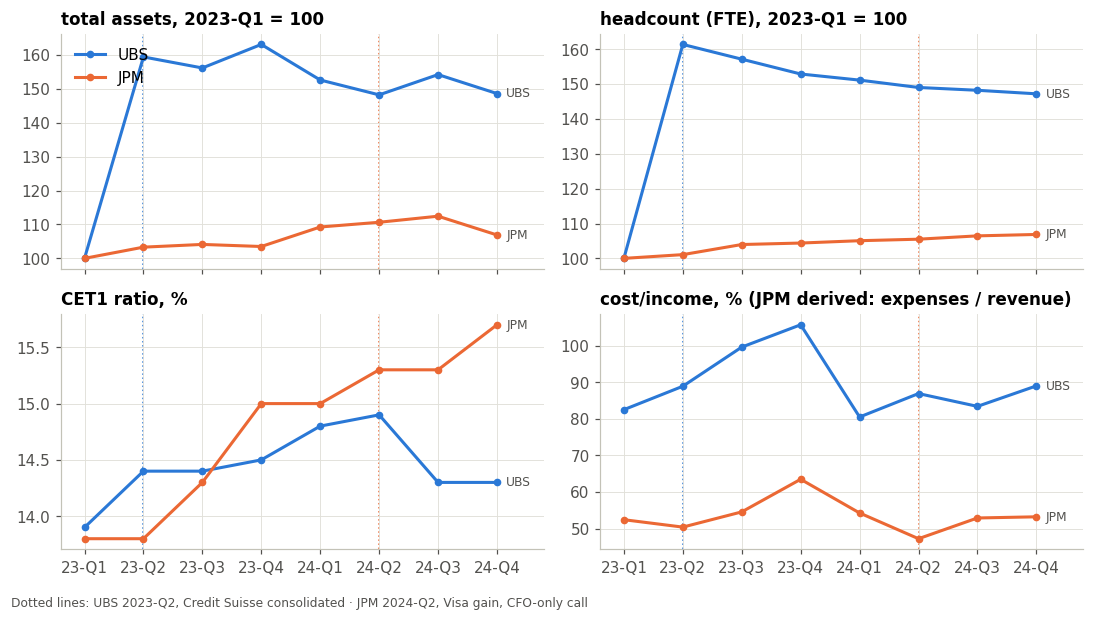

In [57]:
# 2.8 reported figures over time with breaks marked (JPM cost/income is derived, so labelled)
m = (metrics[metrics["basis"] == "reported"]
     .pivot_table(index=["bank", "quarter"], columns="metric_name", values="value"))
first = m.groupby(level="bank").transform("first")                     # 2023-Q1 values
series = {
    "total assets, 2023-Q1 = 100": 100 * m["total_assets"] / first["total_assets"],
    "headcount (FTE), 2023-Q1 = 100": 100 * m["personnel_fte"] / first["personnel_fte"],
    "CET1 ratio, %": m["cet1_ratio"],
    "cost/income, % (JPM derived: expenses / revenue)":
        m["cost_income_ratio"].fillna(100 * m["operating_expenses"] / m["total_revenues"]),
}
fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), sharex=True)
for ax, (title, s) in zip(axes.flat, series.items()):
    bank_lines(ax, s, title)
axes[0, 0].legend(loc="upper left")
fig.text(0.01, 0.005, BREAK_NOTE, fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

The banks' reported figures, for context: UBS's assets and staff jump by about 60% in 2023-Q2 when Credit Suisse is consolidated, and UBS's costs exceed its income in 2023-Q4 (cost/income above 100%). JPMorgan grows steadily.

### Summary

All 17 calls match the README counts. The two banks run their calls differently. UBS opens with long prepared remarks, JPMorgan's calls are mostly Q&A, and JPMorgan management says more per exchange (16 to 33 sentences against 12 to 16 at UBS). UBS executives give much longer single answers (median 228 word-pieces against about 100), and 38% of them exceed MiniLM's 256 limit against 23% at JPMorgan, which is why the analysis runs on sentences. Filler is about 40% of analyst sentences at both banks. No analyst covers both banks, and only 5 of 26 research houses do. Keyword search finds merger talk in 7.2% of UBS and 2.4% of JPMorgan Q&A sentences, and the First Republic deal call gives 19 of JPMorgan's 64. The reported figures show the Credit Suisse step change in 2023-Q2 and UBS's cost/income above 100% in 2023-Q4.

This fills the team's missing EDA and sets the caveats for every comparison: compare shares rather than counts, mark the two break quarters and the deal call, and remember that different analysts ask at each bank.

## Cross-bank comparison

Every sentence is turned into a vector with two Sentence-BERT models, the models are fine-tuned on short example sentences for seven themes, and the fine-tuned tagger measures what each bank talks about, quarter by quarter.

In [58]:
# 4.1 corpus for the comparison: clean Q&A sentences of all 17 calls, the JPM deal call included
display(qa.pivot_table(index=["bank", "speaker_role"], columns="stage_group", values="key",
                       aggfunc="count", margins=True).reindex(columns=STAGE_GROUPS + ["All"]))
print("JPM deal call:", qa[qa["call_type"] == "event"].groupby("speaker_role").size().to_dict())

stage_group        early  closing  integration   All
bank speaker_role                                   
JPM  analyst          83      152          500   735
     management      217      321         1394  1932
UBS  analyst          94      100          506   700
     management      182      202          937  1321
All                  576      775         3337  4688

JPM deal call: {'analyst': 58, 'management': 111}


The sentences used for the bank comparison, by bank, speaker role and deal stage. Most of them (3,337 of 4,688) come after the deals closed; the deal call adds 58 analyst and 111 management sentences to JPMorgan's closing stage.

In [59]:
# 4.2 sentence embeddings with two pre-trained Sentence-BERT models, cached next to the row keys they belong to.
# These are the vectors before fine-tuning; 4.5 adds the fine-tuned ones.
from sentence_transformers import SentenceTransformer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODELS = {"MiniLM": "sentence-transformers/all-MiniLM-L6-v2",
          "mpnet": "sentence-transformers/all-mpnet-base-v2"}

def free_gpu():
    # a SentenceTransformer holds a reference to itself, so `del` alone leaves its weights on the GPU
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

def encode(model, texts, batch_size=64):
    return model.encode([str(t) for t in texts], batch_size=batch_size, normalize_embeddings=True,
                        convert_to_numpy=True, show_progress_bar=False)

def embed(tag, texts, keys, batch_size=64):
    # the corpus now includes the deal call, so the cache has its own name (emb_qa_<model>.npy is the older,
    # earnings-only corpus and stays as it is)
    path, key_path = OUT / f"emb_qa_allcalls_{tag}.npy", OUT / f"emb_qa_allcalls_{tag}_keys.csv"
    if path.exists() and key_path.exists() and pd.read_csv(key_path)["key"].tolist() == list(keys):
        print(f"{tag}: loaded from {path.name}")
        return np.load(path)
    model = SentenceTransformer(MODELS[tag], device=DEVICE)
    t0 = time.time()
    E = encode(model, texts, batch_size)
    print(f"{tag}: {E.shape[0]:,} x {E.shape[1]} in {time.time() - t0:.0f}s on {DEVICE}, "
          f"max_seq_length {model.max_seq_length}")
    np.save(path, E)
    pd.Series(list(keys), name="key").to_csv(key_path, index=False)
    del model
    free_gpu()
    return E

emb = {tag: embed(tag, qa["text"], qa["key"], batch_size=64 if tag == "MiniLM" else 32) for tag in MODELS}
for tag, E in emb.items():
    norms = np.linalg.norm(E, axis=1)
    print(f"{tag:7s} {E.shape[0]:,} x {E.shape[1]}   norms {norms.min():.3f} to {norms.max():.3f}")

MiniLM: loaded from emb_qa_allcalls_MiniLM.npy
mpnet: loaded from emb_qa_allcalls_mpnet.npy
MiniLM  4,688 x 384   norms 1.000 to 1.000
mpnet   4,688 x 768   norms 1.000 to 1.000


Turns each of the 4,688 sentences into a vector with two pre-trained Sentence-BERT models: MiniLM (384 numbers per sentence) and the larger mpnet (768 numbers). Sentences with similar meaning get similar vectors. The vectors were computed once on the laptop GPU (4 and 27 seconds) and are loaded from the saved files on later runs; they are the starting point before any fine-tuning.

### Theme codebook

| Label | Theme | A sentence belongs here when it is mainly about |
|---|---|---|
| `integration` | Integration and M&A | the 2023 acquisition, integration progress and milestones, client or system migration, legal-entity mergers, deal accounting |
| `restructuring` | Restructuring | winding down legacy or non-core books, exiting businesses, reorganisation, restructuring charges |
| `capital` | Capital and liquidity | capital ratios and requirements, buybacks and dividends, RWA and leverage, liquidity, funding, deposit outflows |
| `risk` | Risk and credit quality | credit losses and reserves, loan quality, real-estate exposure, market and rate risk, litigation |
| `costs` | Costs and efficiency | expenses, cost savings, cost/income, headcount, investment spend |
| `revenue` | Revenue and outlook | net interest income and deposit pricing, fees, trading, wealth flows, guidance, client activity |
| `other` | Other | none of the above, or procedure |

One theme per sentence (the main one), judged from the sentence alone. Step 4.3 turns the codebook into eight example sentences per theme, none of which names either bank. These 56 examples are the only labelled data in the notebook: they define the themes, the Sentence-BERT models are fine-tuned on them, and the fine-tuning is checked on them. No transcript sentence is labelled by hand or by an LLM.

In [60]:
# 4.3 theme examples: eight bank-neutral sentences per theme. "other" has its own examples, so a sentence with no
# business topic lands there by similarity; there is no cut-off. A sentence takes the theme whose centroid (the
# average of its eight examples) is closest. This section scores the pre-trained models, before fine-tuning.
from sklearn.metrics import cohen_kappa_score

EXAMPLES = {
    "integration": [
        "The integration of the acquired bank is progressing well and we remain on track with our milestones.",
        "We are migrating the acquired clients and accounts onto our own platforms and systems.",
        "The merger of the two legal entities was completed after the transaction closed.",
        "Purchase accounting, negative goodwill and other acquisition-related effects from the deal.",
        "How is the combination of the two businesses going, and what are the remaining integration risks?",
        "When will the legal entities be merged, and when will the acquired clients be on one platform?",
        "How much of the integration work is still ahead of you, and what are the next milestones?",
        "Most clients of the acquired bank have stayed with us since the takeover.",
    ],
    "restructuring": [
        "We continue to wind down the legacy portfolio and exit businesses that do not fit our strategy.",
        "Running off non-core positions released risk-weighted assets and reduced the balance sheet.",
        "The reorganisation involves closing overlapping units and simplifying the group structure.",
        "Restructuring charges and exit costs were higher this quarter.",
        "How much longer will it take to wind down the remaining legacy book?",
        "We agreed to sell a business that is no longer core to the group.",
        "The run-down of the non-core unit is ahead of plan, with fewer positions left to exit.",
        "We are reorganising our divisions into a simpler structure with fewer layers of management.",
    ],
    "capital": [
        "Our CET1 capital ratio remains well above the regulatory requirement.",
        "We intend to return excess capital to shareholders through share buybacks and dividends.",
        "The proposed capital rules and Basel III requirements would increase the capital we need to hold.",
        "Liquidity and funding remain strong, with a comfortable liquidity coverage ratio.",
        "Risk-weighted assets and the leverage ratio determine how much balance sheet we can deploy.",
        "When do you expect to restart share buybacks, and at what size?",
        "How do you think about the payout split between dividends and buybacks over the next few years?",
        "The capital surcharge and the stress capital buffer set how much capital we must hold.",
    ],
    "risk": [
        "Credit quality remains solid, but we expect net charge-offs to normalise from low levels.",
        "We added to our loan loss reserves because the macroeconomic outlook weakened.",
        "Exposure to commercial real estate and office loans is an area we are watching closely.",
        "Litigation, legal provisions and regulatory investigations remain a risk to earnings.",
        "Market volatility and geopolitical uncertainty could affect the portfolio.",
        "Rates staying higher for longer could strain borrowers and slow the economy.",
        "Card net charge-offs rose as consumer credit continued to normalise.",
        "Higher rates have caused unrealised losses in the securities portfolio.",
    ],
    "costs": [
        "We are on track to deliver the planned gross cost savings.",
        "Expenses rose this quarter, driven by investment in technology and higher compensation.",
        "Our cost-to-income ratio should improve as the efficiency measures come through.",
        "We reduced headcount and contractor spend to bring the cost base down.",
        "What is your expense guidance for next year?",
        "We expect adjusted expenses for next year to be roughly in line with this year.",
        "Compensation costs went up because of higher performance-related pay.",
        "Technology, marketing and real estate were the main drivers of the increase in non-compensation expenses.",
    ],
    "revenue": [
        "Net interest income will come down as deposit costs rise and balances move to higher-yielding products.",
        "Investment banking fees and markets revenue were strong compared with last year.",
        "Wealth management attracted net new assets and fee income grew.",
        "Our outlook assumes modest loan growth and a few rate cuts next year.",
        "Client activity and consumer spending remain healthy.",
        "Net interest income guidance for next year depends on the path of rate cuts and the forward curve.",
        "We are winning back market share and client flows are returning.",
        "What is your outlook for revenue growth and returns over the next few years?",
    ],
    "other": [
        "Thank you, that is very helpful.",
        "Let me take your second question.",
        "I would just add one point to that.",
        "What exactly do you mean by that?",
        "We are not going to comment on speculation.",
        "That is a fair question, and we will come back to it.",
        "We will give you more detail on that at a later date.",
        "I think that is broadly right, and we will see how it plays out.",
    ],
}
THEMES = list(EXAMPLES)
BANK_NAMES = re.compile(r"\b(?:ubs|jp ?morgan|chase|credit suisse|first republic|swiss|switzerland)\b", re.I)
assert not any(BANK_NAMES.search(s) for v in EXAMPLES.values() for s in v), "an example names a bank"
assert all(len(v) == 8 for v in EXAMPLES.values()), "eight examples per theme"
ex_text = np.array([s for v in EXAMPLES.values() for s in v])
ex_label = np.array([t for t, v in EXAMPLES.items() for _ in v])

def centroids(E_ex, labels):
    C = np.vstack([E_ex[labels == t].mean(axis=0) for t in THEMES])
    return C / np.linalg.norm(C, axis=1, keepdims=True)

def tag_themes(E, C):
    # nearest theme centroid, and the margin over the runner-up (how clear-cut the choice is)
    S = E @ C.T
    top2 = np.sort(S, axis=1)[:, -2:]
    return np.array(THEMES)[S.argmax(axis=1)], top2[:, 1] - top2[:, 0]

E_ex_base = {}
for tag in MODELS:
    model = SentenceTransformer(MODELS[tag], device=DEVICE)
    E_ex_base[tag] = encode(model, ex_text)
    del model
    free_gpu()
    qa[f"theme_base_{tag}"], qa[f"margin_base_{tag}"] = tag_themes(emb[tag], centroids(E_ex_base[tag], ex_label))

print("theme shares by bank before fine-tuning (% of sentences)")
display(pd.concat({tag: pd.crosstab(qa[f"theme_base_{tag}"], qa["bank"], normalize="columns").mul(100)
                   for tag in MODELS}, axis=1).reindex(THEMES).fillna(0).round(1))
same = qa["theme_base_MiniLM"] == qa["theme_base_mpnet"]
print(f"MiniLM and mpnet give the same theme for {100 * same.mean():.0f}% of sentences "
      f"(kappa {cohen_kappa_score(qa['theme_base_MiniLM'], qa['theme_base_mpnet']):.2f})")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5088.44it/s]


theme shares by bank before fine-tuning (% of sentences)


MiniLM       mpnet      
bank             JPM   UBS   JPM   UBS
integration      4.2   8.2   4.0   7.7
restructuring    5.7   9.5   2.2   6.3
capital         13.9  17.6  16.1  17.0
risk            21.7   9.0  17.5   7.3
costs            5.2   8.1   5.1   8.5
revenue         17.1  17.7  19.0  19.5
other           32.2  29.9  36.1  33.7

MiniLM and mpnet give the same theme for 64% of sentences (kappa 0.55)


Defines the seven themes with eight example sentences each, none naming a bank, and gives every sentence the theme whose examples it is closest to. Before any fine-tuning, both models already show UBS talking more than JPMorgan about integration, restructuring and costs, and much less about risk. But the two models give the same theme to only 64% of sentences, so the tagging is far from settled.

### Sentence-BERT fine-tuning

The two pre-trained models learned from general web text, not from bank Q&A, and out of the box they often disagree on a sentence's theme. Fine-tuning teaches each model what the seven themes mean, using the 56 examples. The method follows SetFit, a standard recipe for fine-tuning a Sentence-BERT model on a handful of labelled examples:

1. **Pairs.** Every example is paired 20 times with another example of the same theme (target similarity 1) and 20 times with an example of a different theme (target 0): 2,240 pairs.
2. **Training.** The whole network is trained for one pass over the pairs with the cosine-similarity loss (learning rate 2e-5, batches of 16, 10% warm-up), so that sentences on the same theme move closer together and different themes move apart.
3. **Tagging.** Every transcript sentence is tagged exactly as before (nearest theme centroid), now with the fine-tuned vectors.

These are SetFit's default settings, fixed before any result was seen, so nothing is tuned on the checks. The checks need no labelled transcript sentence:

- **Held-out examples (4.4).** Four-fold cross-validation: the model is fine-tuned on six examples per theme and has to place the two it never saw. The pre-trained model is scored the same way, so the difference is the effect of fine-tuning.
- **Stability (4.4).** Each of the four fold models tags the whole corpus. If the tags barely change when a different quarter of the examples is left out, the result does not hang on the wording of a few examples.
- **Agreement between the models (4.5).** MiniLM and mpnet are different networks. If fine-tuning makes them agree more often on real transcript sentences, the themes are better defined.
- **Merger sentences (4.5).** Sentences that mention Credit Suisse, First Republic, an integration, an acquisition or a merger (step 2.7) should mostly land on "integration".

Rule for the final model, fixed in advance: the model that places more held-out examples correctly after fine-tuning; if the two are within two examples of each other, the more stable one.

In [61]:
# 4.4 fine-tuning, and four-fold cross-validation on the theme examples: each fold fine-tunes on 6 examples per
# theme and places the 2 held out; the pre-trained model is scored the same way. Each fold's tagger also tags the
# whole corpus, to see how much the tags depend on which examples were used. 8 fine-tuning runs, a few minutes.
import itertools
from sentence_transformers.sentence_transformer import losses
from sentence_transformers.util import batch_to_device
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

FT = {"pairs_per_example": 20, "epochs": 1, "batch_size": 16, "lr": 2e-5, "warmup": 0.1}   # SetFit defaults

def example_pairs(texts, labels, rng):
    # every example gets pairs_per_example same-theme partners (target 1) and as many other-theme ones (target 0)
    pairs, idx = [], np.arange(len(labels))
    for _ in range(FT["pairs_per_example"]):
        for i, t in enumerate(labels):
            same, other = idx[(labels == t) & (idx != i)], idx[labels != t]
            pairs += [(texts[i], texts[rng.choice(same)], 1.0), (texts[i], texts[rng.choice(other)], 0.0)]
    return pairs

def fine_tune(tag, texts, labels, seed=SEED):
    # SetFit's first stage: contrastive training of the whole Sentence-BERT model on example pairs.
    # Returns the model and the loss of every training step.
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    model = SentenceTransformer(MODELS[tag], device=DEVICE)
    loss_fn = losses.CosineSimilarityLoss(model)
    pairs = example_pairs([str(t) for t in texts], np.asarray(labels), rng)
    steps = FT["epochs"] * int(np.ceil(len(pairs) / FT["batch_size"]))
    opt = torch.optim.AdamW(model.parameters(), lr=FT["lr"])
    sched = get_linear_schedule_with_warmup(opt, int(FT["warmup"] * steps), steps)
    model.train()
    log = []
    for _ in range(FT["epochs"]):
        order = rng.permutation(len(pairs))
        for start in range(0, len(pairs), FT["batch_size"]):
            batch = [pairs[i] for i in order[start:start + FT["batch_size"]]]
            a, b = (batch_to_device(model.preprocess([p[k] for p in batch]), model.device) for k in (0, 1))
            y = torch.tensor([p[2] for p in batch], dtype=torch.float32, device=model.device)
            loss = loss_fn([a, b], y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            sched.step()
            log.append(loss.item())
    opt.zero_grad(set_to_none=True)                        # drop the last gradients, no longer needed
    model.eval()
    return model, log

folds = list(StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED).split(ex_text, ex_label))
cv_rows, fold_tags = [], {}
t0 = time.time()
for tag in MODELS:
    for k, (tr, te) in enumerate(folds):
        C = centroids(E_ex_base[tag][tr], ex_label[tr])                     # before: pre-trained model
        cv_rows += [{"model": tag, "stage": "before", "fold": k, "example": i, "theme": ex_label[i], "predicted": p}
                    for i, p in zip(te, tag_themes(E_ex_base[tag][te], C)[0])]
        fold_tags[tag, "before", k] = tag_themes(emb[tag], C)[0]
        model, _ = fine_tune(tag, ex_text[tr], ex_label[tr], seed=SEED + k)  # after: fine-tuned on this fold only
        C = centroids(encode(model, ex_text[tr]), ex_label[tr])
        cv_rows += [{"model": tag, "stage": "after", "fold": k, "example": i, "theme": ex_label[i], "predicted": p}
                    for i, p in zip(te, tag_themes(encode(model, ex_text[te]), C)[0])]
        fold_tags[tag, "after", k] = tag_themes(encode(model, qa["text"], batch_size=128), C)[0]
        del model
        free_gpu()
print(f"{len(MODELS) * len(folds)} fine-tuning runs in {(time.time() - t0) / 60:.1f} min on {DEVICE}")
cv = pd.DataFrame(cv_rows)
cv["correct"] = cv["theme"] == cv["predicted"]
cv.to_csv(OUT / "finetune_cv_examples.csv", index=False)

boot = np.random.default_rng(SEED).integers(0, len(ex_label), size=(1000, len(ex_label)))
cv_summary = []
for (tag, stage), g in cv.groupby(["model", "stage"], sort=False):
    ok = g.sort_values("example")["correct"].to_numpy()
    lo, hi = np.percentile(100 * ok[boot].mean(axis=1), [2.5, 97.5])
    runs = [fold_tags[tag, stage, k] for k in range(len(folds))]
    cv_summary.append({"model": tag, "stage": stage, "held-out right": f"{ok.sum()} of {len(ok)}",
                       "accuracy %": 100 * ok.mean(), "95% low": lo, "95% high": hi,
                       "macro-F1": f1_score(g["theme"], g["predicted"], average="macro"),
                       "tags unchanged across folds %":
                           100 * np.mean([(a == b).mean() for a, b in itertools.combinations(runs, 2)])})
cv_summary = pd.DataFrame(cv_summary).set_index(["model", "stage"])
display(cv_summary.round(2))
print("held-out examples placed correctly, per theme (of 8)")
display(cv.pivot_table(index="theme", columns=["model", "stage"], values="correct", aggfunc="sum")
        .reindex(index=THEMES, columns=pd.MultiIndex.from_product([list(MODELS), ["before", "after"]])))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11059.87it/s]


8 fine-tuning runs in 8.4 min on cuda


held-out right  accuracy %  95% low  95% high  macro-F1  \
model  stage                                                            
MiniLM before       44 of 56       78.57    67.86     87.50      0.79   
       after        45 of 56       80.36    69.64     89.29      0.80   
mpnet  before       43 of 56       76.79    66.07     87.50      0.76   
       after        50 of 56       89.29    82.14     96.43      0.89   

               tags unchanged across folds %  
model  stage                                  
MiniLM before                          73.03  
       after                           71.33  
mpnet  before                          75.27  
       after                           76.21

held-out examples placed correctly, per theme (of 8)


MiniLM        mpnet      
              before after before after
theme                                  
integration        7     7      7     8
restructuring      5     5      6     6
capital            6     7      7     8
risk               5     4      4     5
costs              7     8      6     7
revenue            6     6      5     8
other              8     8      8     8

Tests what fine-tuning adds, using only the theme examples: each model is fine-tuned on six examples per theme and must place the two it has not seen, four times over (eight training runs, about 8 minutes on the laptop GPU). mpnet improves from 43 to 50 correct out of 56 (77% to 89%), while MiniLM barely moves (44 to 45). About three sentences in four keep their theme when a different quarter of the examples is left out, before and after, so fine-tuning did not make the tags more stable.

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9694.44it/s]


MiniLM: 140 steps in 24s, loss 0.257 (first 10 steps) to 0.086 (last 10)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9773.73it/s]


mpnet: 140 steps in 130s, loss 0.230 (first 10 steps) to 0.009 (last 10)


,,held-out examples right %,tags unchanged across folds %,same theme as the other model %,merger sentences tagged integration %,other %,median margin
model,stage,,,,,,
MiniLM,before,78.6,73.0,63.6,29.2,31.2,0.1
mpnet,before,76.8,75.3,63.6,34.9,35.1,0.1
MiniLM,after,80.4,71.3,61.7,35.9,29.5,0.1
mpnet,after,89.3,76.2,61.7,44.5,35.8,0.2


MiniLM against mpnet, before fine-tuning: kappa 0.55
MiniLM against mpnet, after fine-tuning: kappa 0.53
held-out examples right after fine-tuning: {'MiniLM': 45, 'mpnet': 50} of 56  ->  chosen model: mpnet


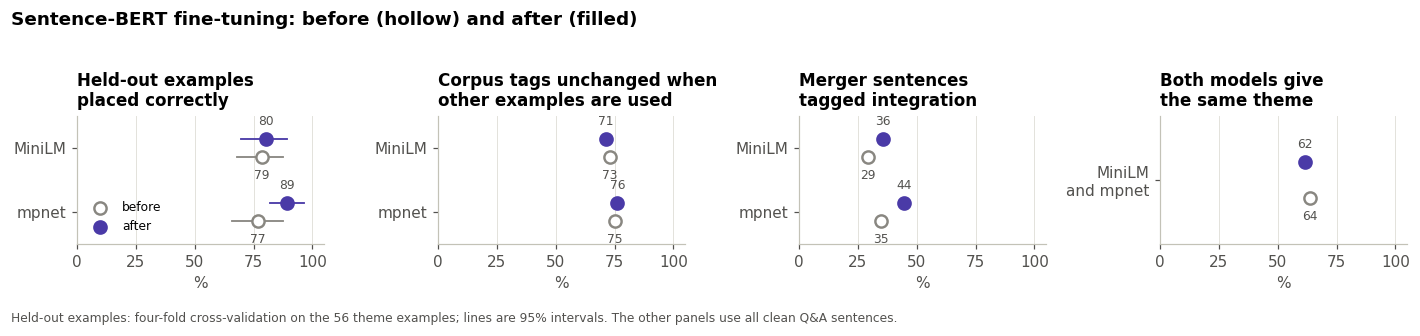

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.89it/s]


wrote themes_sentence.csv (4,688 sentences) and the fine-tuned model sbert_themes_mpnet/


In [62]:
# 4.5 the final fine-tuning: each model trained on all 56 examples, then the whole corpus tagged again. Before and
# after on real transcript sentences, the chart for the fine-tuning slide, and the final model by the rule above.
# The chosen model's fine-tuned weights, the fine-tuned vectors and every sentence's theme are saved.
ft_models, emb_ft, loss_log = {}, {}, {}
for tag in MODELS:
    t0 = time.time()
    ft_models[tag], loss_log[tag] = fine_tune(tag, ex_text, ex_label)
    emb_ft[tag] = encode(ft_models[tag], qa["text"], batch_size=128)
    C = centroids(encode(ft_models[tag], ex_text), ex_label)
    qa[f"theme_ft_{tag}"], qa[f"margin_ft_{tag}"] = tag_themes(emb_ft[tag], C)
    np.save(OUT / f"emb_qa_allcalls_{tag}_finetuned.npy", emb_ft[tag])
    print(f"{tag}: {len(loss_log[tag])} steps in {time.time() - t0:.0f}s, loss {np.mean(loss_log[tag][:10]):.3f} "
          f"(first 10 steps) to {np.mean(loss_log[tag][-10:]):.3f} (last 10)")

rows = []
for stage, p in (("before", "base"), ("after", "ft")):
    both = qa[f"theme_{p}_MiniLM"] == qa[f"theme_{p}_mpnet"]
    for tag in MODELS:
        t = qa[f"theme_{p}_{tag}"]
        rows.append({"model": tag, "stage": stage,
                     "held-out examples right %": cv_summary.loc[(tag, stage), "accuracy %"],
                     "tags unchanged across folds %": cv_summary.loc[(tag, stage), "tags unchanged across folds %"],
                     "same theme as the other model %": 100 * both.mean(),
                     "merger sentences tagged integration %": 100 * (t[qa["merger_keyword"]] == "integration").mean(),
                     "other %": 100 * (t == "other").mean(),
                     "median margin": qa[f"margin_{p}_{tag}"].median()})
diag = pd.DataFrame(rows).set_index(["model", "stage"])
display(diag.round(1))
for stage, p in (("before", "base"), ("after", "ft")):
    print(f"MiniLM against mpnet, {stage} fine-tuning: kappa "
          f"{cohen_kappa_score(qa[f'theme_{p}_MiniLM'], qa[f'theme_{p}_mpnet']):.2f}")

acc = cv[cv["stage"] == "after"].groupby("model")["correct"].sum()
best, runner = acc.idxmax(), acc.idxmin()
CHOSEN = best if acc[best] - acc[runner] > 2 else diag.xs("after", level="stage")["tags unchanged across folds %"].idxmax()
print(f"held-out examples right after fine-tuning: {acc.to_dict()} of {len(ex_label)}  ->  chosen model: {CHOSEN}")

# chart: before (hollow, grey) and after (filled) for each check; lines are 95% intervals
STAGE_STYLE = {"before": {"facecolors": "white", "edgecolors": "#898781"},
               "after": {"facecolors": "#4a3aa7", "edgecolors": "#4a3aa7"}}
OFFSET = {"before": 0.14, "after": -0.14}

def before_after(ax, values, title, intervals=None):
    # values: {row label: {stage: value}}; intervals: {row label: {stage: (low, high)}}
    for y, (label, v) in enumerate(values.items()):
        for stage in ("before", "after"):
            yy = y + OFFSET[stage]
            if intervals:
                lo, hi = intervals[label][stage]
                ax.plot([lo, hi], [yy, yy], color=STAGE_STYLE[stage]["edgecolors"], lw=1.2, zorder=2)
            ax.scatter([v[stage]], [yy], s=64, linewidths=1.6, zorder=3, label=stage if y == 0 else None,
                       **STAGE_STYLE[stage])
            up = stage == "after"                          # after-labels above, before-labels below
            ax.annotate(f"{v[stage]:.0f}", (v[stage], yy), xytext=(0, 7 if up else -8), textcoords="offset points",
                        ha="center", va="bottom" if up else "top", fontsize=8, color="#52514e")
    ax.set_yticks(range(len(values)), list(values))
    ax.set_ylim(len(values) - 0.5, -0.5)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, 105)
    ax.set_xlabel("%")
    ax.set_title(title, loc="left")

def per_model(col):
    return {t: {s: diag.loc[(t, s), col] for s in ("before", "after")} for t in MODELS}

ci = {t: {s: tuple(cv_summary.loc[(t, s), ["95% low", "95% high"]]) for s in ("before", "after")} for t in MODELS}
fig, axes = plt.subplots(1, 4, figsize=(13, 2.9))
before_after(axes[0], per_model("held-out examples right %"), "Held-out examples\nplaced correctly", ci)
before_after(axes[1], per_model("tags unchanged across folds %"), "Corpus tags unchanged when\nother examples are used")
before_after(axes[2], per_model("merger sentences tagged integration %"), "Merger sentences\ntagged integration")
before_after(axes[3], {"MiniLM\nand mpnet": per_model("same theme as the other model %")["MiniLM"]},
             "Both models give\nthe same theme")
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("Sentence-BERT fine-tuning: before (hollow) and after (filled)", x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, "Held-out examples: four-fold cross-validation on the 56 theme examples; lines are 95% "
         "intervals. The other panels use all clean Q&A sentences.", fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.05, 1, 0.95))
fig.savefig(FIG / "fig_4.5_finetuning.png", dpi=150, bbox_inches="tight")
plt.show()

qa["theme"] = qa[f"theme_ft_{CHOSEN}"]
ft_models[CHOSEN].save(str(OUT / f"sbert_themes_{CHOSEN}"))
qa[["key", "sentence_id", "call_type", "theme"] + [f"theme_{p}_{t}" for p in ("base", "ft") for t in MODELS]] \
    .to_csv(OUT / "themes_sentence.csv", index=False)
del ft_models
free_gpu()
print(f"wrote themes_sentence.csv ({len(qa):,} sentences) and the fine-tuned model sbert_themes_{CHOSEN}/")

Fine-tunes both models on all 56 examples and compares them before and after on the real transcript sentences; mpnet is chosen by the rule set in advance (50 against 45 held-out examples right). Fine-tuning makes mpnet more decisive and sends more merger sentences to integration (35% to 44%). It does not make the two models agree more often (64% before, 62% after), so the gain on real sentences is modest.

In [63]:
# 4.5b what fine-tuning changed for the chosen model: theme before (rows) against after (columns); the UBS-minus-
# JPM difference per theme before and after, for both models; and sentences from the three largest moves.
# Prints transcript text: clear outputs before committing.
print(f"{CHOSEN}: theme before fine-tuning (rows) against after (columns), sentences")
display(pd.crosstab(qa[f"theme_base_{CHOSEN}"], qa["theme"], margins=True)
        .reindex(index=THEMES + ["All"], columns=THEMES + ["All"], fill_value=0))

gaps = {}
for stage, p in (("before", "base"), ("after", "ft")):
    for tag in MODELS:
        s = pd.crosstab(qa[f"theme_{p}_{tag}"], qa["bank"], normalize="columns").reindex(THEMES, fill_value=0) * 100
        gaps[f"{tag} {stage}"] = s["UBS"] - s["JPM"]
gaps = pd.DataFrame(gaps)
print("UBS share minus JPM share, percentage points (positive: UBS gives the theme more of its Q&A)")
display(gaps.round(1))
same_sign = gaps.drop(index="other").apply(lambda r: (np.sign(r) == np.sign(r.iloc[0])).all(), axis=1)
print("same direction before and after, in both models:", same_sign.to_dict())

moves = (qa[qa[f"theme_base_{CHOSEN}"] != qa["theme"]]
         .groupby([f"theme_base_{CHOSEN}", "theme"]).size().nlargest(3))
for (was, now), n in moves.items():
    print(f"\n{was} -> {now}: {n} sentences, for example")
    moved = qa[(qa[f"theme_base_{CHOSEN}"] == was) & (qa["theme"] == now)]
    for _, r in moved.sample(3, random_state=SEED).iterrows():
        print(f"   {r['bank']} {r['quarter']} {r['speaker_role'][:4]}  {r['text'][:160]}")

mpnet: theme before fine-tuning (rows) against after (columns), sentences


theme,integration,restructuring,capital,risk,costs,revenue,other,All
theme_base_mpnet,,,,,,,,
integration,161,16,12,7,3,17,46,262
restructuring,9,120,7,8,14,4,25,187
capital,16,19,573,33,7,66,59,773
risk,7,17,63,355,4,134,35,615
costs,10,2,17,4,214,25,34,306
revenue,36,20,63,75,26,616,65,901
other,31,36,37,43,19,66,1412,1644
All,270,230,772,525,287,928,1676,4688


UBS share minus JPM share, percentage points (positive: UBS gives the theme more of its Q&A)


,MiniLM before,mpnet before,MiniLM after,mpnet after
integration,3.9,3.7,3.2,5.3
restructuring,3.9,4.0,6.2,5.5
capital,3.7,0.9,3.8,0.4
risk,-12.7,-10.2,-11.9,-8.3
costs,2.9,3.4,2.6,3.9
revenue,0.6,0.5,0.1,-3.1
other,-2.3,-2.4,-4.1,-3.6


same direction before and after, in both models: {'integration': True, 'restructuring': True, 'capital': True, 'risk': True, 'costs': True, 'revenue': False}

risk -> revenue: 134 sentences, for example
   UBS 2024-Q3 mana  And for sure, that asset band tends to have a much lower percentage of AuM in sweeps.
   JPM 2024-Q1 mana  And I think the single most notable thing is just this effect, where in the – while it is true that real incomes have gone up in the lowest income cohorts, with
   JPM 2024-Q4 anal  Is it loan growth inflecting?

revenue -> risk: 75 sentences, for example
   JPM 2023-Q1 mana  There are some tailwinds in there through the OCI, but we believe there will likely be some offsets and harsher credit shocks in the number, so for planning pur
   UBS 2024-Q2 anal  And now you alluded to the close of the US mortgage servicing business will get you some way towards that.
   JPM 2023-Q2 anal  Would love to hear, Jamie, your thoughts or, Jamie, your comments around do you th

Shows what fine-tuning changed for mpnet. Three sentences in four keep their theme (3,451 of 4,688); the largest moves are between risk and revenue, and the sample sentences show a mix of corrections and doubtful cases. The UBS-against-JPMorgan differences keep their direction in both models for every theme except revenue, which is roughly even before fine-tuning and leans to JPMorgan after it.

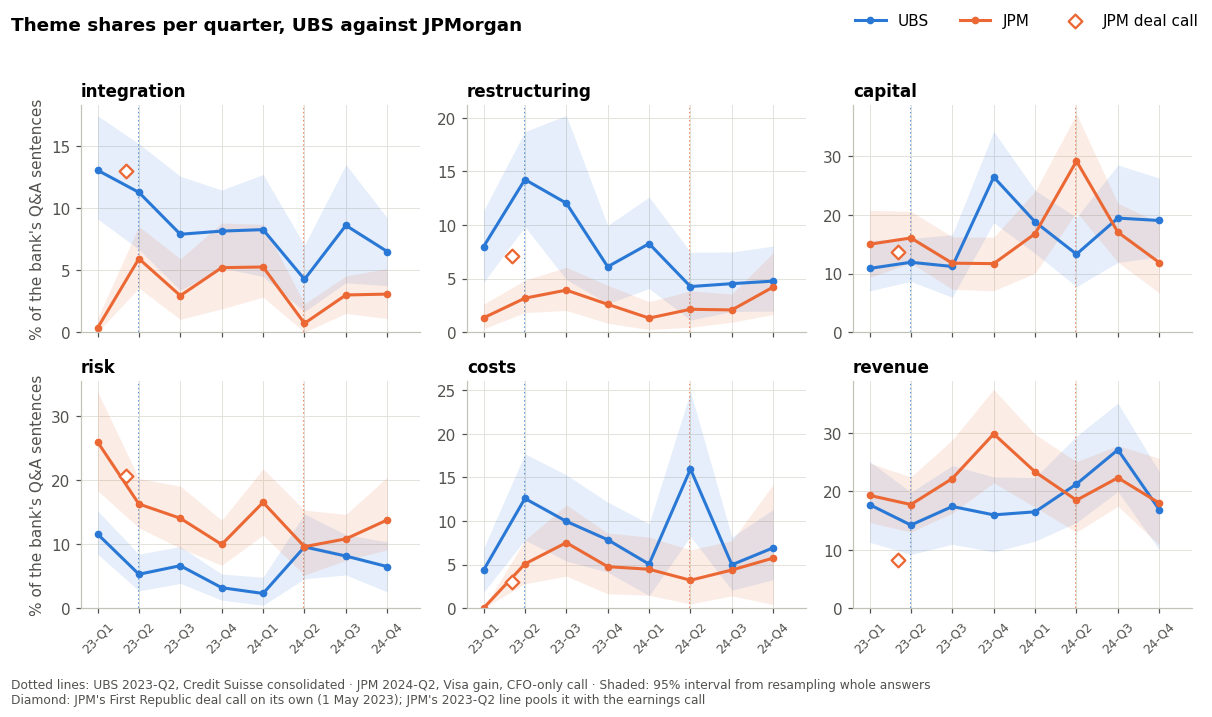

theme share by bank and deal stage (% of sentences)


UBS                       JPM                    
              early closing integration early closing integration
theme                                                            
integration    13.0    11.3         7.4   0.3     5.9         3.4
restructuring   8.0    14.2         6.7   1.3     3.2         2.6
capital        10.9    11.9        18.8  15.0    16.1        16.6
risk           11.6     5.3         5.8  26.0    16.3        12.6
costs           4.3    12.6         8.2   0.0     5.1         5.0
revenue        17.8    14.2        18.8  19.3    17.8        22.3
other          34.4    30.5        34.2  38.0    35.7        37.6

what the deal call adds to JPMorgan (% of sentences)


,"UBS, all calls","JPM, all calls","JPM, earnings calls only",JPM 2023-Q2 earnings call,JPM deal call
theme,,,,,
integration,8.8,3.5,2.8,2.0,13.0
restructuring,8.0,2.5,2.2,1.0,7.1
capital,16.7,16.3,16.5,17.4,13.6
risk,6.5,14.8,14.4,13.8,20.7
costs,8.4,4.4,4.5,6.2,3.0
revenue,18.0,21.1,22.0,23.0,8.3
other,33.7,37.3,37.5,36.5,34.3


In [64]:
# 4.6 theme prevalence: share of each bank's clean Q&A sentences per theme and quarter (fine-tuned tagger, 4.5).
# 95% intervals come from resampling whole utterances, not sentences: sentences in one answer are not
# independent, so the answer is the unit that is resampled. JPM 2023-Q2 pools the earnings call and the deal
# call; the diamond shows the deal call alone.
B = 1000

def resample_weights(rng, n_units, n=B):
    # n bootstrap samples as counts: row i says how often each unit was drawn in sample i
    W = np.zeros((n, n_units))
    np.add.at(W, (np.arange(n)[:, None], rng.integers(0, n_units, size=(n, n_units))), 1)
    return W

def theme_shares(df, rng):
    # point shares per theme, and B bootstrap replicates from resampled utterances
    counts = pd.crosstab(df["turn_id"], df["theme"]).reindex(columns=THEMES, fill_value=0).to_numpy()
    boot = resample_weights(rng, len(counts)) @ counts
    return counts.sum(axis=0) / counts.sum(), boot / boot.sum(axis=1, keepdims=True)

rng = np.random.default_rng(SEED)
records = []
for (b, q), g in qa.groupby(["bank", "quarter"]):
    point, boot = theme_shares(g, rng)
    lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
    records += [{"bank": b, "quarter": q, "theme": t, "share": 100 * point[k], "lo": 100 * lo[k],
                 "hi": 100 * hi[k]} for k, t in enumerate(THEMES)]
prevalence = pd.DataFrame(records)
prevalence.round(2).to_csv(OUT / "theme_shares_bank_quarter.csv", index=False)
deal_call = pd.Series(100 * theme_shares(qa[qa["call_type"] == "event"], rng)[0], index=THEMES)

x = np.arange(len(QUARTERS))
fig, axes = plt.subplots(2, 3, figsize=(11, 6.4), sharex=True)
for ax, t in zip(axes.flat, [t for t in THEMES if t != "other"]):
    p = prevalence[prevalence["theme"] == t].set_index(["bank", "quarter"])
    for b in BANKS:
        s = p.xs(b, level="bank").reindex(QUARTERS)
        ax.fill_between(x, s["lo"], s["hi"], color=BANK_COLOR[b], alpha=0.12, lw=0)
        ax.plot(x, s["share"], color=BANK_COLOR[b], marker="o", ms=4, label=b)
    mark_event(ax, deal_call[t])
    quarter_axis(ax)
    mark_breaks(ax)
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_title(t, loc="left")
    ax.set_ylim(bottom=0)
for ax in axes[:, 0]:
    ax.set_ylabel("% of the bank's Q&A sentences")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper right", ncol=3)
fig.suptitle("Theme shares per quarter, UBS against JPMorgan", x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, BREAK_NOTE + " · Shaded: 95% interval from resampling whole answers\n" + EVENT_NOTE
         + "; JPM's 2023-Q2 line pools it with the earnings call", fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.05, 1, 0.96))
fig.savefig(FIG / "fig_4.6_theme_shares.png", dpi=150, bbox_inches="tight")
plt.show()

print("theme share by bank and deal stage (% of sentences)")
display(qa.pivot_table(index="theme", columns=["bank", "stage_group"], values="key", aggfunc="count")
        .div(qa.groupby(["bank", "stage_group"]).size(), axis=1).mul(100).round(1)
        .reindex(index=THEMES, columns=pd.MultiIndex.from_product([BANKS, STAGE_GROUPS])).fillna(0))

print("what the deal call adds to JPMorgan (% of sentences)")
jpm = qa[qa["bank"] == "JPM"]
views = {"UBS, all calls": qa[qa["bank"] == "UBS"], "JPM, all calls": jpm,
         "JPM, earnings calls only": jpm[jpm["call_type"] == "earnings"],
         "JPM 2023-Q2 earnings call": jpm[(jpm["quarter"] == "2023-Q2") & (jpm["call_type"] == "earnings")],
         "JPM deal call": jpm[jpm["call_type"] == "event"]}
display(pd.DataFrame({k: v["theme"].value_counts(normalize=True).reindex(THEMES, fill_value=0) * 100
                      for k, v in views.items()}).round(1))

Theme shares per quarter, with 95% ranges from resampling whole answers. UBS gives more of its Q&A than JPMorgan to integration (8.8% against 3.5%), restructuring (8.0% against 2.5%) and costs (8.4% against 4.4%), and JPMorgan more to risk (14.8% against 6.5%), most of all in early 2023. The First Republic deal call is JPMorgan's most merger-focused call (13% integration, 21% risk), and it lifts JPMorgan's 2023-Q2 integration share from 2% to about 6%.

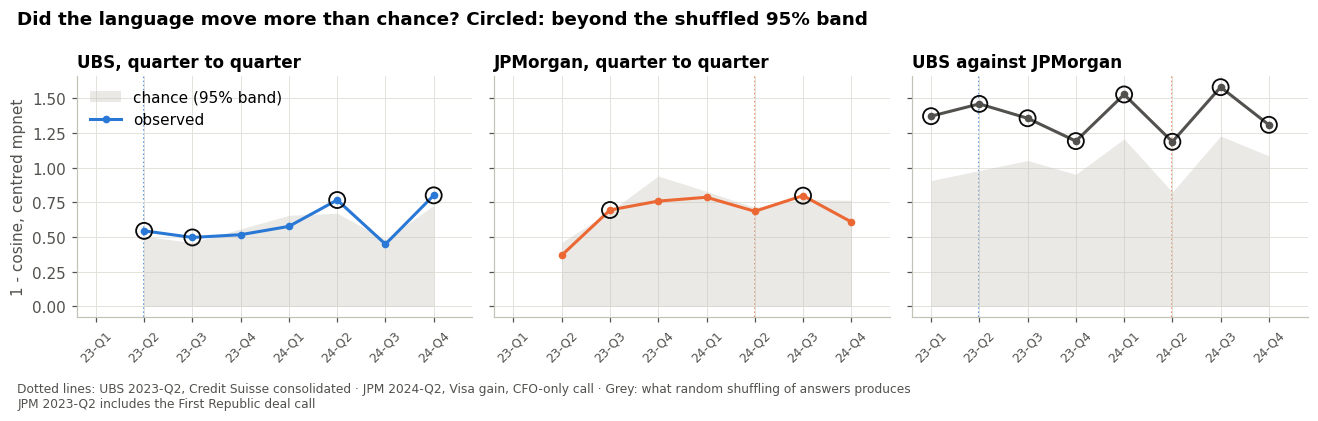

steps beyond chance, out of those tested


variant,"mpnet, pre-trained","MiniLM, pre-trained","mpnet, fine-tuned","mpnet, pre-trained, earnings calls only"
measure,,,,
UBS-JPM distance,8 of 8,8 of 8,8 of 8,8 of 8
UBS drift,4 of 7,5 of 7,4 of 7,4 of 7
JPM drift,2 of 7,2 of 7,0 of 7,1 of 7


correlation of the excess over chance with the main run: {'MiniLM, pre-trained': np.float64(0.98), 'mpnet, fine-tuned': np.float64(0.95), 'mpnet, pre-trained, earnings calls only': np.float64(0.98)}


measure,JPM drift,UBS drift,UBS-JPM distance
quarter,,,
2023-Q1,NaN,NaN,0.6827
2023-Q2,0.0528,0.1895,0.7074
2023-Q3,0.1792,0.1769,0.4900
2023-Q4,0.0345,0.1258,0.4849
2024-Q1,0.1503,0.1138,0.5343
2024-Q2,0.1574,0.2863,0.5707
2024-Q3,0.2297,0.1111,0.5744
2024-Q4,0.0629,0.2699,0.4321


In [65]:
# 4.7 semantic drift, tested against chance. Embeddings are centred on the pooled mean, so the banking vocabulary
# both banks share cancels out, then averaged per bank-quarter. Drift = 1 - cosine between the two centroids.
# Centroids of a few hundred sentences are noisy (two random halves of one quarter already differ by about as
# much as two quarters), so every figure is compared with a chance level: the same measure after shuffling whole
# utterances between the two groups, 500 times. Only a value above the shuffled 95% band is a real change.
# The main run uses the chosen model's pre-trained vectors on purpose: drift should catch any change in language,
# not only change along the seven themes the models were fine-tuned on. Three checks: the other model, the
# fine-tuned vectors, and the earnings calls alone (deal call left out, so one call per quarter).
N_SHUFFLE = 500
OTHER = next(t for t in MODELS if t != CHOSEN)
ALL = pd.Series(True, index=qa.index)
VARIANTS = {f"{CHOSEN}, pre-trained": (emb[CHOSEN], ALL),
            f"{OTHER}, pre-trained": (emb[OTHER], ALL),
            f"{CHOSEN}, fine-tuned": (emb_ft[CHOSEN], ALL),
            f"{CHOSEN}, pre-trained, earnings calls only": (emb[CHOSEN], qa["call_type"] == "earnings")}
MAIN = next(iter(VARIANTS))

def unit(X):
    return X / np.linalg.norm(X, axis=-1, keepdims=True)

def utterance_sums(E, g):
    codes, units = pd.factorize(g["turn_id"])
    sums = np.zeros((len(units), E.shape[1]))
    np.add.at(sums, codes, E[g.index.to_numpy()])
    return sums, np.bincount(codes)

def distance_vs_chance(sums_a, n_a, sums_b, n_b, rng):
    # 1 - cosine between the two groups' centroids, and the same after shuffling utterances between the groups
    observed = 1 - unit(sums_a.sum(0) / n_a.sum()) @ unit(sums_b.sum(0) / n_b.sum())
    S, n = np.vstack([sums_a, sums_b]), np.concatenate([n_a, n_b])
    in_a = np.zeros((N_SHUFFLE, len(n)))
    for i in range(N_SHUFFLE):
        in_a[i, rng.permutation(len(n))[:len(n_a)]] = 1
    ca, cb = unit((in_a @ S) / (in_a @ n)[:, None]), unit(((1 - in_a) @ S) / ((1 - in_a) @ n)[:, None])
    null = 1 - (ca * cb).sum(axis=1)
    return observed, null.mean(), np.percentile(null, 97.5)

rng = np.random.default_rng(SEED)
drift_rows = []
for name, (E, rows) in VARIANTS.items():
    used = qa[rows]
    Ec = E - E[used.index].mean(axis=0)
    parts = {(b, q): utterance_sums(Ec, g) for (b, q), g in used.groupby(["bank", "quarter"])}
    for i, q in enumerate(QUARTERS):
        for b in BANKS:
            if i > 0:
                obs, chance, band = distance_vs_chance(*parts[b, QUARTERS[i - 1]], *parts[b, q], rng)
                drift_rows.append({"variant": name, "measure": f"{b} drift", "quarter": q,
                                   "observed": obs, "chance": chance, "chance 95%": band})
        obs, chance, band = distance_vs_chance(*parts["UBS", q], *parts["JPM", q], rng)
        drift_rows.append({"variant": name, "measure": "UBS-JPM distance", "quarter": q,
                           "observed": obs, "chance": chance, "chance 95%": band})
drift = pd.DataFrame(drift_rows)
drift["beyond chance"] = drift["observed"] > drift["chance 95%"]
drift["excess"] = drift["observed"] - drift["chance"]
drift.round(4).to_csv(OUT / "drift_bank_quarter.csv", index=False)

d = drift[drift["variant"] == MAIN]
x = np.arange(len(QUARTERS))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharey=True)
panels = [("UBS drift", BANK_COLOR["UBS"], "UBS, quarter to quarter", ["UBS"]),
          ("JPM drift", BANK_COLOR["JPM"], "JPMorgan, quarter to quarter", ["JPM"]),
          ("UBS-JPM distance", "#52514e", "UBS against JPMorgan", BANKS)]
for ax, (m, color, title, breaks) in zip(axes, panels):
    s = d[d["measure"] == m].set_index("quarter").reindex(QUARTERS)
    ax.fill_between(x, 0, s["chance 95%"], color="#c3c2b7", alpha=0.35, lw=0, label="chance (95% band)")
    ax.plot(x, s["observed"], color=color, marker="o", ms=4, label="observed")
    hits = s["beyond chance"].eq(True).to_numpy()          # the first quarter has no previous one
    ax.scatter(x[hits], s["observed"].to_numpy()[hits], s=110, facecolors="none", edgecolors="#0b0b0b", lw=1.2,
               zorder=3)
    quarter_axis(ax)
    mark_breaks(ax, breaks)
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_title(title, loc="left")
axes[0].set_ylabel(f"1 - cosine, centred {CHOSEN}")
axes[0].legend(loc="upper left")
fig.suptitle("Did the language move more than chance? Circled: beyond the shuffled 95% band",
             x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, BREAK_NOTE + " · Grey: what random shuffling of answers produces\n"
         "JPM 2023-Q2 includes the First Republic deal call", fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.07, 1, 1))
fig.savefig(FIG / "fig_4.7_drift_vs_chance.png", dpi=150, bbox_inches="tight")
plt.show()

print("steps beyond chance, out of those tested")
display(drift.groupby(["measure", "variant"], sort=False)["beyond chance"]
        .agg(lambda s: f"{s.sum()} of {s.count()}").unstack("variant")[list(VARIANTS)])
wide = drift.pivot_table(index=["measure", "quarter"], columns="variant", values="excess")
print("correlation of the excess over chance with the main run:",
      {v: round(wide[MAIN].corr(wide[v]), 2) for v in VARIANTS if v != MAIN})
display(d.pivot(index="quarter", columns="measure", values="excess").reindex(QUARTERS).round(4))

Tests whether each bank's language changed from one quarter to the next by more than chance, comparing each change with 500 random reshuffles of the answers. UBS changed beyond chance in 4 of 7 steps and JPMorgan in 2 of 7; without the deal call JPMorgan drops to 1 of 7, so the deal call is what makes its step into 2023-Q3 stand out. The banks differ beyond chance in every quarter, most in the first half of 2023, and the pattern holds with the other model and with the fine-tuned vectors (correlation 0.95 to 0.98).

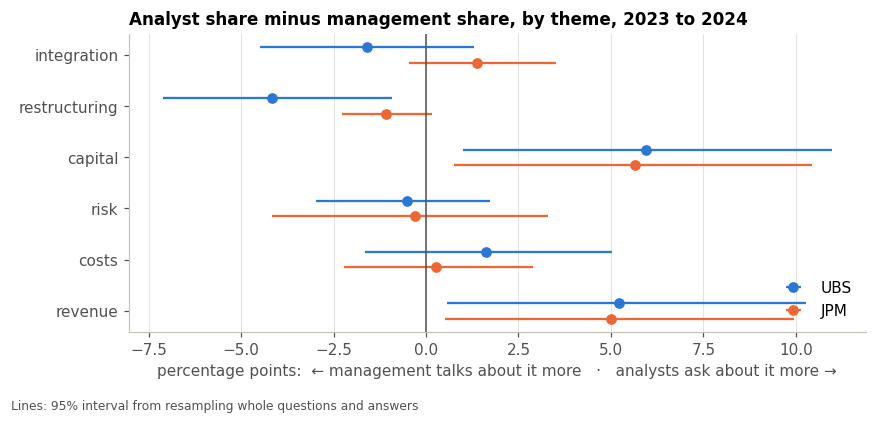

gap by deal stage (percentage points; early = 2023-Q1, closing = 2023-Q2)


UBS                             JPM                          
               all early closing integration   all early closing integration
theme                                                                       
integration   -1.6   1.2    -9.4        -0.5   1.4  -0.5     3.9         0.8
restructuring -4.2  -4.0    -1.9        -4.6  -1.1  -1.8    -0.8        -1.1
capital        6.0   6.1     3.1         6.4   5.7   9.2    10.3         3.8
risk          -0.5   5.0    -0.4        -1.6  -0.3   2.4    -2.7        -0.3
costs          1.6  -0.1    -2.4         2.8   0.3   0.0     0.3         0.3
revenue        5.2   3.7     4.1         5.7   5.0   4.9    -2.9         7.5
other         -6.5 -11.9     6.8        -8.3 -10.9 -14.2    -8.1       -11.1

In [66]:
# 4.8 analysts against management: theme share among analyst sentences minus the share among management
# sentences, in percentage points. Positive: analysts raise the theme more than management talks about it.
# Whole period and by deal stage; 95% intervals from resampling utterances within each role.
rng = np.random.default_rng(SEED)
gap_rows = []
for b in BANKS:
    for stage in ["all"] + STAGE_GROUPS:
        g = qa[(qa["bank"] == b) & ((qa["stage_group"] == stage) | (stage == "all"))]
        (pa, ba), (pm, bm) = (theme_shares(g[g["speaker_role"] == r], rng) for r in ROLES)
        lo, hi = np.percentile(100 * (ba - bm), [2.5, 97.5], axis=0)
        gap_rows += [{"bank": b, "stage": stage, "theme": t, "gap": 100 * (pa[k] - pm[k]), "lo": lo[k], "hi": hi[k]}
                     for k, t in enumerate(THEMES)]
gap = pd.DataFrame(gap_rows)
gap.round(2).to_csv(OUT / "analyst_management_gap.csv", index=False)

shown = [t for t in THEMES if t != "other"]
g = gap[gap["stage"] == "all"].set_index(["bank", "theme"])
fig, ax = plt.subplots(figsize=(8, 3.8))
y = np.arange(len(shown))
for i, b in enumerate(BANKS):
    r = g.xs(b, level="bank").reindex(shown)
    yy = y + (i - 0.5) * 0.3
    ax.errorbar(r["gap"], yy, xerr=[r["gap"] - r["lo"], r["hi"] - r["gap"]], fmt="o", ms=6,
                color=BANK_COLOR[b], ecolor=BANK_COLOR[b], elinewidth=1.5, capsize=0, label=b)
ax.axvline(0, color="#52514e", lw=1)
ax.set_yticks(y, shown)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("percentage points:  ← management talks about it more   ·   analysts ask about it more →")
ax.legend(loc="lower right")
ax.set_title("Analyst share minus management share, by theme, 2023 to 2024", loc="left")
fig.text(0.01, 0.005, "Lines: 95% interval from resampling whole questions and answers", fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(FIG / "fig_4.8_analyst_gap.png", dpi=150, bbox_inches="tight")
plt.show()

print("gap by deal stage (percentage points; early = 2023-Q1, closing = 2023-Q2)")
display(gap.pivot_table(index="theme", columns=["bank", "stage"], values="gap")
        .reindex(index=THEMES, columns=pd.MultiIndex.from_product([BANKS, ["all"] + STAGE_GROUPS])).round(1))

Compares what analysts ask about with what management talks about. At both banks analysts bring up capital and revenue more often than management does (by about 6 and 5 percentage points), and UBS management talks more about restructuring than its analysts ask about it (by 4 points). Management also says more that fits no theme; the other differences, risk included, are within noise.

### Summary

The 4,688 clean Q&A sentences, JPMorgan's First Republic deal call included, were embedded with two Sentence-BERT models (MiniLM and mpnet) and tagged with one of seven themes (integration, restructuring, capital, risk, costs, revenue, other) by their similarity to eight example sentences per theme that never name either bank. Both models were then fine-tuned on those 56 examples with the SetFit recipe, using its default settings, fixed in advance. On examples held out of training, fine-tuning raised mpnet from 43 to 50 correct out of 56 (77% to 89%) and left MiniLM almost unchanged (44 to 45), so mpnet was chosen by the rule set beforehand. On the real transcript sentences the gain is modest: the fine-tuned mpnet chooses more decisively and sends more merger sentences to integration (35% to 44%), but the two models agree no more often than before (64%, then 62%), and the tags are no more stable when a different set of examples is used.

The differences between the banks keep their direction before and after fine-tuning and in both models. With the fine-tuned mpnet, UBS gives more of its Q&A to integration (8.8% of sentences against 3.5%), restructuring (8.0% against 2.5%) and costs (8.4% against 4.4%), and JPMorgan more to risk (14.8% against 6.5%). Capital is about even. Revenue is the one theme whose direction depends on the setting: roughly even before fine-tuning, JPMorgan ahead after it (21.1% against 18.0%). The deal call is JPMorgan's most merger-focused call (13% integration), and it lifts JPMorgan's 2023-Q2 integration share from 2% to about 6%. UBS's language changed beyond chance in 4 of 7 quarter-to-quarter steps against 2 of 7 for JPMorgan (1 of 7 without the deal call), and the two banks differ beyond chance in every quarter, most in the first half of 2023. At both banks analysts ask more about capital and revenue than management talks about them.

Caveats: no transcript sentence is labelled, so the fine-tuning is checked on held-out examples, which are written in the same style as the training ones, and on agreement and stability measures that cannot prove accuracy. Different analysts cover the two banks (5 of 26 research houses in common). Themes are one per sentence, about a third of sentences fit no theme, and the two break quarters (UBS 2023-Q2, JPMorgan 2024-Q2) are marked on every chart.

Benchmarking UBS against a peer that went through the same rate cycle and regulation separates the merger signal from the sector signal: the integration, restructuring and cost themes, and the more frequent quarter-to-quarter movement, are UBS's own, while JPMorgan's merger talk is concentrated in one deal call. The method runs on a laptop, keeps text in-house and applies to any bank with transcripts.

## Next

Model comparison, later and with the team: topic similarity with the BERTopic run and sentiment by theme with the FinBERT labels, both joined on the sentence key in `themes_sentence.csv`, and the LLM answer key when the team picks its LLM. The fine-tuned model is saved in `sbert_themes_<model>/`, so it can tag the prepared remarks (`prepared_sentences.parquet`) for A3. Before any commit: clear all outputs (public repository, N23) and add only this notebook.